<a href="https://colab.research.google.com/github/Sabinx87/SAM-Dental/blob/main/Dental.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install transformers datasets peft accelerate monai albumentations -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 8.3 MB/s eta 0:00:00


In [ ]:
# Load model directly
from transformers import AutoProcessor, AutoModelForMaskGeneration

processor = AutoProcessor.from_pretrained("facebook/sam-vit-base")
model = AutoModelForMaskGeneration.from_pretrained("facebook/sam-vit-base", device_map="auto")

preprocessor_config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/6.57k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  375MB            

model.safetensors: downloading bytes:           |  0.00B            

ValueError: max() iterable argument is empty

In [ ]:
import numpy as np
from PIL import Image, ImageDraw
import json

import os

json_path = "/content/drive/MyDrive/dentex_train/training_data/quadrant-enumeration-disease/train_quadrant_enumeration_disease.json"
with open(json_path) as f:
    data = json.load(f)

caries_annotations = [
    ann for ann in data["annotations"]
    if ann["category_id_3"] == 1
]
print(f"Total caries annotations: {len(caries_annotations)}")


image_lookup = {img["id"]: img for img in data["images"]}

def polygon_to_mask(segmentation, width, height):
    mask = Image.new("L", (width, height), 0)
    for poly in segmentation:
        points = [(poly[i], poly[i+1]) for i in range(0, len(poly), 2)]
        ImageDraw.Draw(mask).polygon(points, outline=1, fill=1)
    return np.array(mask)

image_dir = "/content/drive/MyDrive/dentex_train/training_data/quadrant-enumeration-disease/xrays"

dataset_pairs = []

for ann in caries_annotations:
    img_info = image_lookup[ann["image_id"]]
    image_path = os.path.join(image_dir, img_info["file_name"])

    if not os.path.exists(image_path):
        continue

    mask = polygon_to_mask(ann["segmentation"], img_info["width"], img_info["height"])
    box = ann["bbox"]

    dataset_pairs.append({
        "image_path": image_path,
        "mask": mask,
        "box": box,
        "image_id": ann["image_id"]
    })

print(f"Built {len(dataset_pairs)} image-mask-box pairs")

Total caries annotations: 2189
Built 2175 image-mask-box pairs


In [ ]:
unique_images = set(p["image_id"] for p in dataset_pairs)
print(f"Unique images with caries: {len(unique_images)}")

Unique images with caries: 621


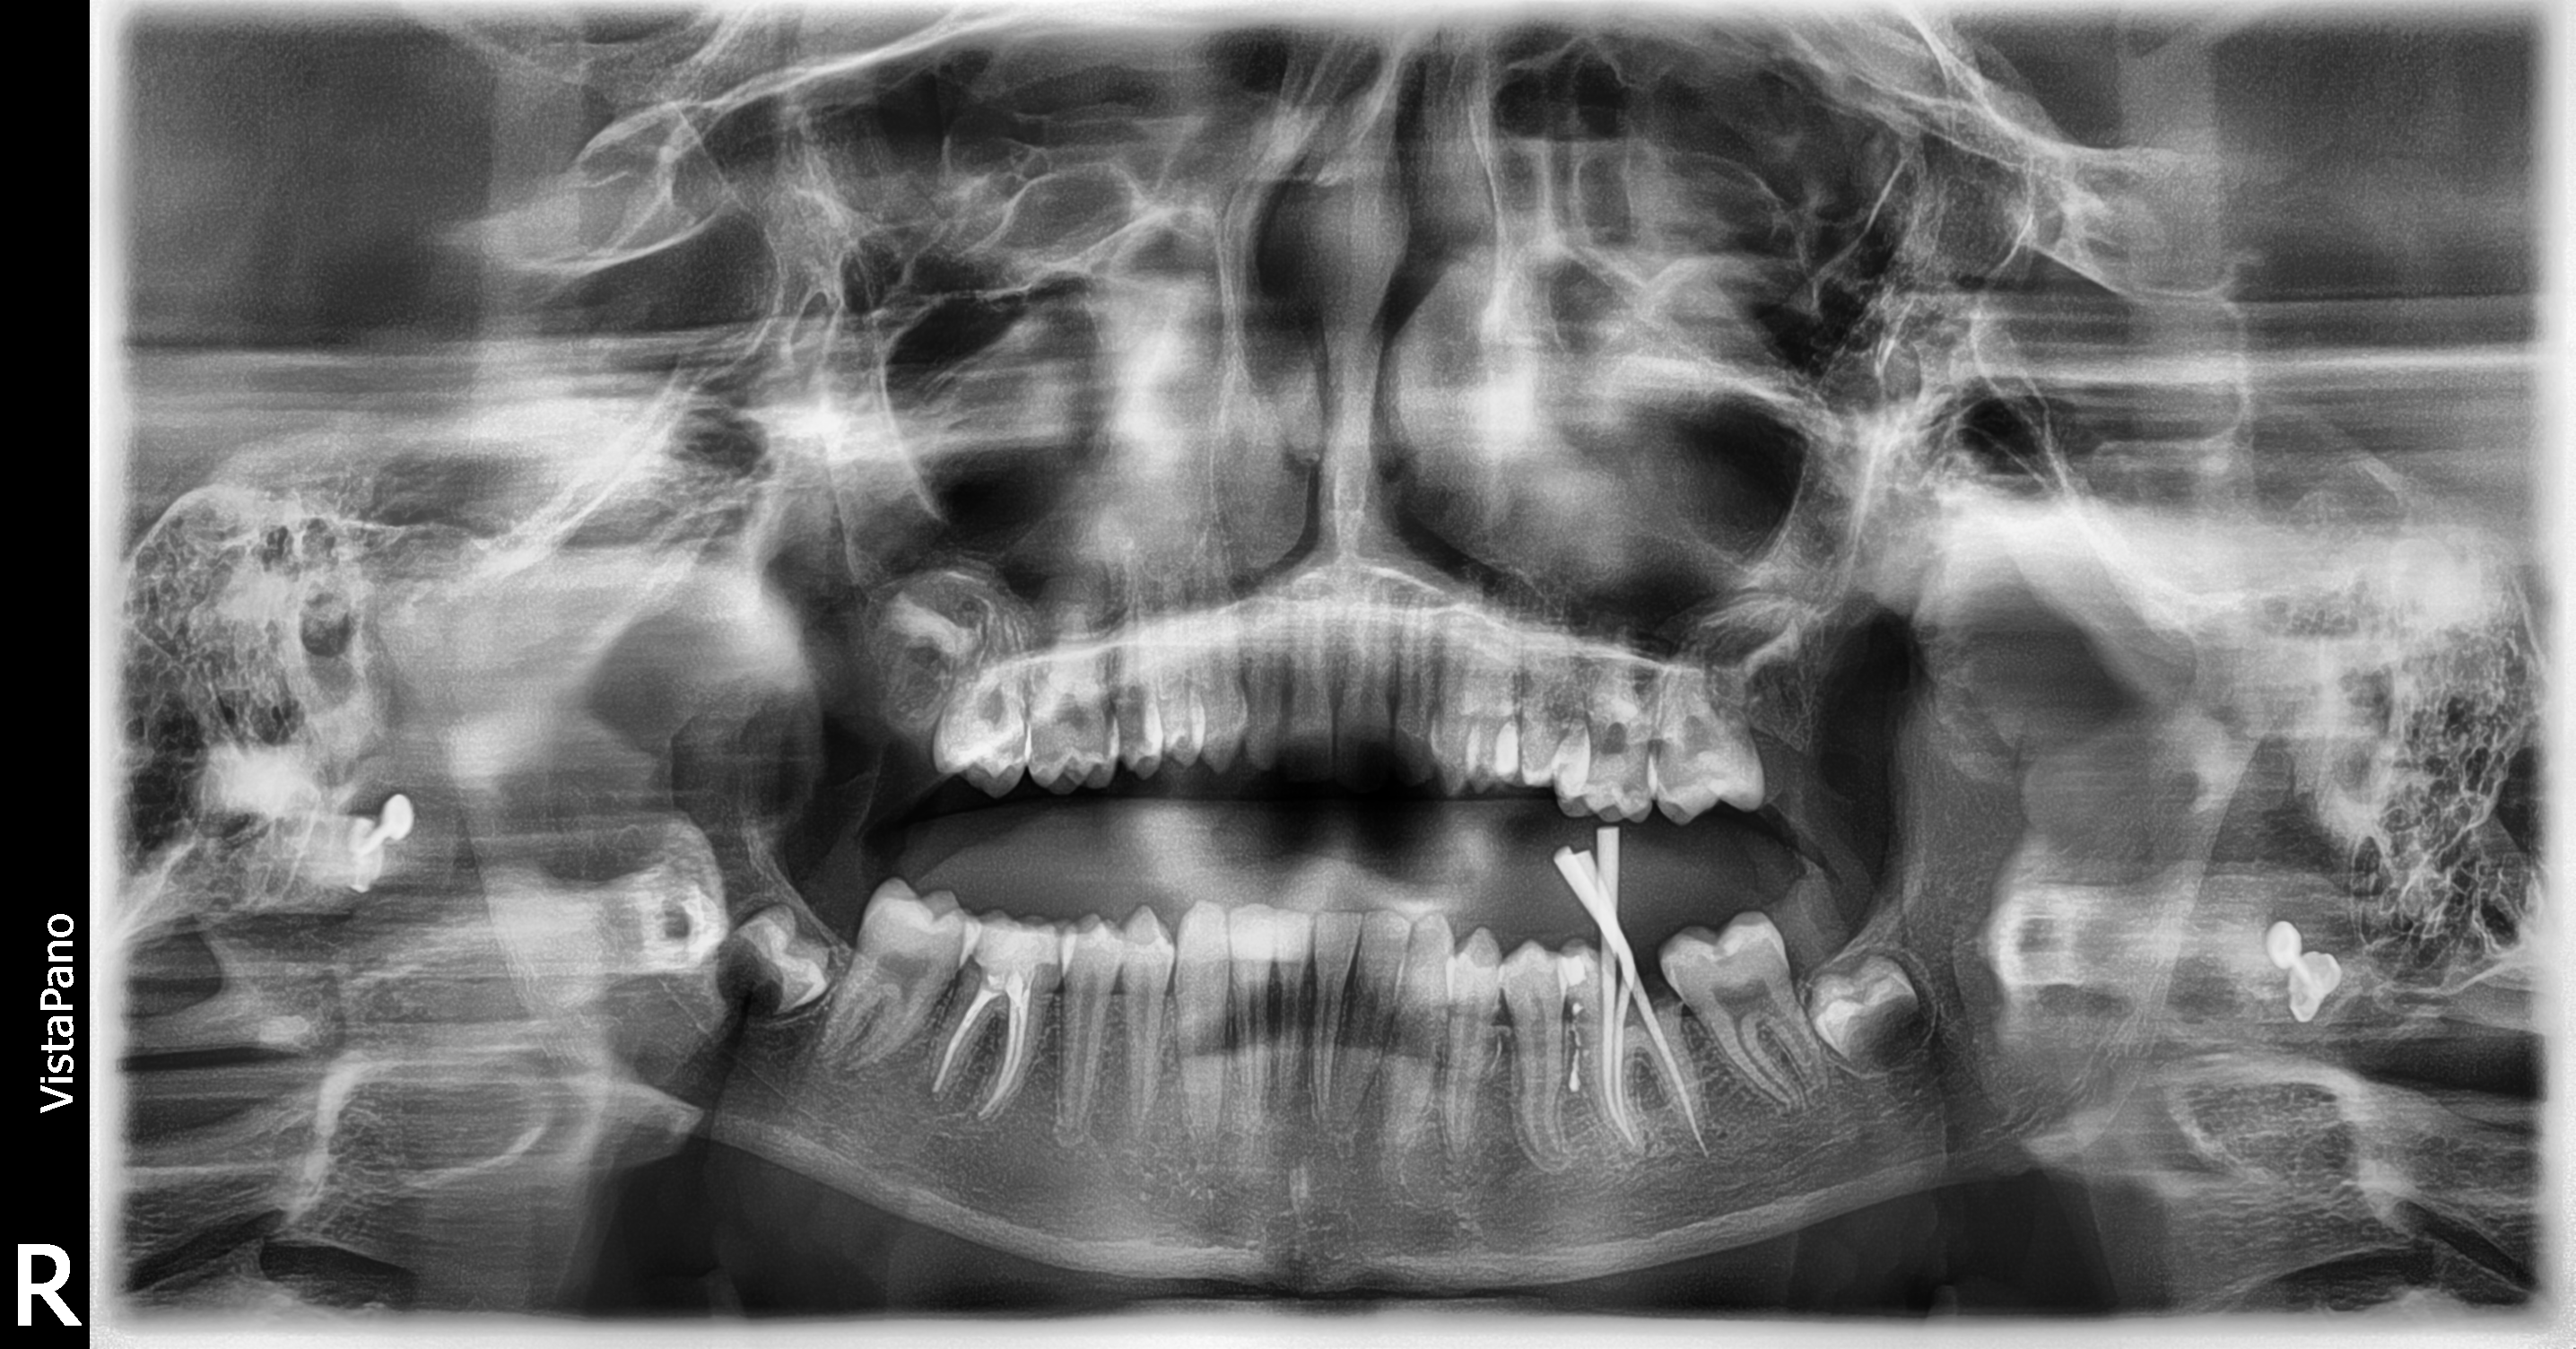

In [ ]:

from PIL import Image

image=Image.open(dataset_pairs[0]["image_path"])
mask=dataset_pairs[0]["mask"]

image



In [ ]:
import random

random.seed(42)

unique_images_ids=list(unique_images)
random.shuffle(unique_images_ids)

selected_ids=unique_images_ids[:100]
train_ids=set(selected_ids[:50])
test_ids=set(selected_ids[50:])


print(f"Train images: {len(train_ids)}")
print(f"Test images: {len(test_ids)}")


Train images: 50
Test images: 50


In [ ]:
train_pairs=[p for p in dataset_pairs if p["image_id"] in train_ids]
test_pairs=[p for p in dataset_pairs if p["image_id"] in test_ids]

print(f"Train pairs: {len(train_pairs)}")
print(f"Test pairs: {len(test_pairs)}")

Train pairs: 178
Test pairs: 171


In [ ]:
import random

random.seed(42)
unique_image_ids = list(unique_images)
random.shuffle(unique_image_ids)

TOTAL_IMAGES = 100
selected_ids = unique_image_ids[:TOTAL_IMAGES]
train_ids = set(selected_ids[:TOTAL_IMAGES // 2])
test_ids = set(selected_ids[TOTAL_IMAGES // 2:])

print(f"Train images: {len(train_ids)} | Test images: {len(test_ids)}")

train_pairs_full = [p for p in dataset_pairs if p["image_id"] in train_ids]
test_pairs = [p for p in dataset_pairs if p["image_id"] in test_ids]
print(f"Train lesions: {len(train_pairs_full)} | Test lesions: {len(test_pairs)}")

train_ids_list = list(train_ids)
random.shuffle(train_ids_list)

for n in [10, 20, 50]:
    subset_ids = set(train_ids_list[:n])
    subset_pairs = [p for p in train_pairs_full if p["image_id"] in subset_ids]
    print(f"{n}-image subset: {len(subset_pairs)} lesions")
    globals()[f"train_pairs_{n}"] = subset_pairs

Train images: 50 | Test images: 50
Train lesions: 178 | Test lesions: 171
10-image subset: 24 lesions
20-image subset: 71 lesions
50-image subset: 178 lesions


In [ ]:
!pip uninstall torchao -y -q

In [ ]:
from peft import LoraConfig, get_peft_model

lora_config=LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["qkv","q_proj", "v_proj"],
    lora_dropout=0.1,
    bias="none",
    task_type="FEATURE_EXTRACTION"
)
model=get_peft_model(model,lora_config)
model.print_trainable_parameters()

NameError: name 'model' is not defined

In [ ]:
import shutil, os
##Done
src = "/content/drive/MyDrive/dentex_train/training_data/quadrant-enumeration-disease/xrays"
local_xrays = "/content/xrays_local"

if not os.path.exists(local_xrays):
    shutil.copytree(src, local_xrays)

print("Images copied locally:", len(os.listdir(local_xrays)))

Images copied locally: 703


In [ ]:
for p in dataset_pairs:
    filename = os.path.basename(p["image_path"])
    p["image_path"] = os.path.join(local_xrays, filename)

print("Paths updated. Example:", dataset_pairs[0]["image_path"])

NameError: name 'local_xrays' is not defined

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from tqdm import tqdm
import gc

In [ ]:
def polygon_to_mask(segmentation, width, height):
    mask = Image.new("L", (width, height), 0)
    for poly in segmentation:
        points = [(poly[i], poly[i+1]) for i in range(0, len(poly), 2)]
        ImageDraw.Draw(mask).polygon(points, outline=1, fill=1)
    return np.array(mask)

class CariesDataset(Dataset):
    def __init__(self, pairs, processor, train=True):
        self.pairs = pairs
        self.processor = processor
        self.train = train

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        item = self.pairs[idx]
        image = Image.open(item["image_path"]).convert("RGB")
        orig_w, orig_h = image.size

        # Build mask fresh, right here, only for this one sample
        full_mask = polygon_to_mask(item["segmentation"], item["width"], item["height"])

        image.thumbnail((MAX_SIZE, MAX_SIZE), Image.LANCZOS)
        new_w, new_h = image.size
        scale_x, scale_y = new_w / orig_w, new_h / orig_h

        mask_img = Image.fromarray(full_mask).resize((new_w, new_h), Image.NEAREST)
        mask = np.array(mask_img).astype(np.float32)

        box = item["box"]
        scaled_box = [box[0]*scale_x, box[1]*scale_y, box[2]*scale_x, box[3]*scale_y]

        if self.train:
            box_xyxy = jitter_box(scaled_box, jitter_px=10, img_w=new_w, img_h=new_h)
        else:
            box_xyxy = [scaled_box[0], scaled_box[1], scaled_box[0]+scaled_box[2], scaled_box[1]+scaled_box[3]]

        inputs = self.processor(image, input_boxes=[[box_xyxy]], return_tensors="pt")
        inputs = {k: v.squeeze(0) for k, v in inputs.items()}
        inputs["gt_mask"] = torch.tensor(mask)
        return inputs

NameError: name 'Dataset' is not defined

In [ ]:
import torch.nn.functional as F

def dice_loss(pred, target, eps=1e-6):
    pred = torch.sigmoid(pred)
    pred = pred.flatten()
    target = target.flatten()
    intersection = (pred * target).sum()
    return 1 - (2 * intersection + eps) / (pred.sum() + target.sum() + eps)

In [ ]:
def collate_fn(batch):
    return batch[0]

In [ ]:
import gc
from tqdm import tqdm

# Confirm GPU
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Using:", torch.cuda.get_device_name(0))

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

train_dataset = CariesDataset(train_pairs_10, processor, train=True)
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, collate_fn=collate_fn)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

NUM_EPOCHS = 20
checkpoint_dir = "/content/drive/MyDrive/sam-dental/checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        gt_mask = batch.pop("gt_mask").to(device)
        inputs = {k: v.unsqueeze(0).to(device) for k, v in batch.items()}

        outputs = model(**inputs)
        pred_mask = outputs.pred_masks[:, :, 0]
        pred_mask = F.interpolate(pred_mask, size=gt_mask.shape[-2:], mode="bilinear", align_corners=False)
        pred_mask = pred_mask.squeeze()

        loss = dice_loss(pred_mask, gt_mask)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Memory cleanup - important fix for the crash
        del outputs, pred_mask, loss, inputs, gt_mask
        gc.collect()
        torch.cuda.empty_cache()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1} | Avg Dice Loss: {avg_loss:.4f}")

    model.save_pretrained(f"{checkpoint_dir}/epoch_{epoch+1}")

CUDA available: True
Using: Tesla T4


NameError: name 'model' is not defined

In [ ]:
!pip uninstall torchao -y -q
!pip install transformers peft accelerate -q

In [ ]:
# 1. Imports
import json, os, random, gc
import numpy as np
from PIL import Image, ImageDraw
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

from google.colab import drive

drive.mount('/content/drive')

# 2. Lightweight dataset rebuild (segmentation-based, no pre-rendered masks)
json_path = "/content/drive/MyDrive/dentex_train/training_data/quadrant-enumeration-disease/train_quadrant_enumeration_disease.json"
with open(json_path) as f:
    data = json.load(f)

caries_annotations = [ann for ann in data["annotations"] if ann["category_id_3"] == 1]
image_lookup = {img["id"]: img for img in data["images"]}
image_dir = "/content/drive/MyDrive/dentex_train/training_data/quadrant-enumeration-disease/xrays"

dataset_pairs = []
for ann in caries_annotations:
    img_info = image_lookup[ann["image_id"]]
    image_path = os.path.join(image_dir, img_info["file_name"])
    if not os.path.exists(image_path):
        continue
    dataset_pairs.append({
        "image_path": image_path,
        "segmentation": ann["segmentation"],
        "box": ann["bbox"],
        "image_id": ann["image_id"],
        "width": img_info["width"],
        "height": img_info["height"],
    })

print(f"Built {len(dataset_pairs)} lightweight pairs")

# 3. Train/test split
unique_images = set(p["image_id"] for p in dataset_pairs)
random.seed(42)
unique_image_ids = list(unique_images)
random.shuffle(unique_image_ids)

TOTAL_IMAGES = 100
selected_ids = unique_image_ids[:TOTAL_IMAGES]
train_ids = set(selected_ids[:TOTAL_IMAGES // 2])
test_ids = set(selected_ids[TOTAL_IMAGES // 2:])

train_pairs_full = [p for p in dataset_pairs if p["image_id"] in train_ids]
test_pairs = [p for p in dataset_pairs if p["image_id"] in test_ids]

train_ids_list = list(train_ids)
random.shuffle(train_ids_list)

for n in [10, 20, 50]:
    subset_ids = set(train_ids_list[:n])
    subset_pairs = [p for p in train_pairs_full if p["image_id"] in subset_ids]
    globals()[f"train_pairs_{n}"] = subset_pairs

print(f"Train: {len(train_ids)} | Test: {len(test_ids)}")
print(f"train_pairs_10: {len(train_pairs_10)}")

# 4. Model + LoRA
!pip install transformers peft accelerate -q
from transformers import AutoProcessor, AutoModelForMaskGeneration
from peft import LoraConfig, get_peft_model

processor = AutoProcessor.from_pretrained("facebook/sam-vit-base")
model = AutoModelForMaskGeneration.from_pretrained("facebook/sam-vit-base")
model.to("cuda" if torch.cuda.is_available() else "cpu")

lora_config = LoraConfig(
    r=8, lora_alpha=16,
    target_modules=["qkv", "q_proj", "v_proj"],
    lora_dropout=0.1, bias="none",
    task_type="FEATURE_EXTRACTION"
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Built 2175 lightweight pairs
Train: 50 | Test: 50
train_pairs_10: 24


Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

trainable params: 342,016 || all params: 94,077,744 || trainable%: 0.3635


In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU - go to Runtime > Change runtime type > T4 GPU")

True
Tesla T4


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:

MAX_SIZE = 1024

def polygon_to_mask(segmentation, width, height):
    mask = Image.new("L", (width, height), 0)
    for poly in segmentation:
        points = [(poly[i], poly[i+1]) for i in range(0, len(poly), 2)]
        ImageDraw.Draw(mask).polygon(points, outline=1, fill=1)
    return np.array(mask)

def jitter_box(box_xywh, jitter_px=10, img_w=None, img_h=None):
    x, y, w, h = box_xywh
    x_min, y_min, x_max, y_max = x, y, x + w, y + h
    x_min -= np.random.randint(0, jitter_px)
    y_min -= np.random.randint(0, jitter_px)
    x_max += np.random.randint(0, jitter_px)
    y_max += np.random.randint(0, jitter_px)
    if img_w: x_min, x_max = max(0, x_min), min(img_w, x_max)
    if img_h: y_min, y_max = max(0, y_min), min(img_h, y_max)
    return [x_min, y_min, x_max, y_max]

def dice_loss(pred, target, eps=1e-6):
    pred = torch.sigmoid(pred)
    pred = pred.flatten()
    target = target.flatten()
    intersection = (pred * target).sum()
    return 1 - (2 * intersection + eps) / (pred.sum() + target.sum() + eps)

def collate_fn(batch):
    return batch[0]

class CariesDataset(Dataset):
    def __init__(self, pairs, processor, train=True):
        self.pairs = pairs
        self.processor = processor
        self.train = train

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        item = self.pairs[idx]
        image = Image.open(item["image_path"]).convert("RGB")
        orig_w, orig_h = image.size

        full_mask = polygon_to_mask(item["segmentation"], item["width"], item["height"])

        image.thumbnail((MAX_SIZE, MAX_SIZE), Image.LANCZOS)
        new_w, new_h = image.size
        scale_x, scale_y = new_w / orig_w, new_h / orig_h

        mask_img = Image.fromarray(full_mask).resize((new_w, new_h), Image.NEAREST)
        mask = np.array(mask_img).astype(np.float32)

        box = item["box"]
        scaled_box = [box[0]*scale_x, box[1]*scale_y, box[2]*scale_x, box[3]*scale_y]

        if self.train:
            box_xyxy = jitter_box(scaled_box, jitter_px=10, img_w=new_w, img_h=new_h)
        else:
            box_xyxy = [scaled_box[0], scaled_box[1], scaled_box[0]+scaled_box[2], scaled_box[1]+scaled_box[3]]

        inputs = self.processor(image, input_boxes=[[box_xyxy]], return_tensors="pt")
        inputs = {k: v.squeeze(0) for k, v in inputs.items()}
        inputs["gt_mask"] = torch.tensor(mask)
        return inputs

#training
train_dataset = CariesDataset(train_pairs_50, processor, train=True)
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, collate_fn=collate_fn)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

NUM_EPOCHS = 20
checkpoint_dir = "/content/drive/MyDrive/sam-dental/checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

#training loop
for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        gt_mask = batch.pop("gt_mask").to(device)
        inputs = {k: v.unsqueeze(0).to(device) for k, v in batch.items()}

        outputs = model(**inputs)
        pred_mask = outputs.pred_masks[:, :, 0]
        pred_mask = F.interpolate(pred_mask, size=gt_mask.shape[-2:], mode="bilinear", align_corners=False)
        pred_mask = pred_mask.squeeze()

        loss = dice_loss(pred_mask, gt_mask)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        del outputs, pred_mask, loss, inputs, gt_mask
        gc.collect()
        torch.cuda.empty_cache()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1} | Avg Dice Loss: {avg_loss:.4f}")

    model.save_pretrained(f"{checkpoint_dir}/epoch_{epoch+1}")

Epoch 1: 100%|██████████| 178/178 [05:24<00:00,  1.82s/it]


Epoch 1 | Avg Dice Loss: 0.9666


Epoch 2: 100%|██████████| 178/178 [04:57<00:00,  1.67s/it]


Epoch 2 | Avg Dice Loss: 0.3984


Epoch 3: 100%|██████████| 178/178 [05:02<00:00,  1.70s/it]


...

Epoch 18 | Avg Dice Loss: 0.1793


Epoch 19: 100%|██████████| 178/178 [04:55<00:00,  1.66s/it]


Epoch 19 | Avg Dice Loss: 0.1737


Epoch 20: 100%|██████████| 178/178 [04:57<00:00,  1.67s/it]


Epoch 20 | Avg Dice Loss: 0.1708


In [ ]:
import json, os, random
import numpy as np
from PIL import Image, ImageDraw
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset
from tqdm import tqdm
from transformers import AutoProcessor, AutoModelForMaskGeneration
from peft import PeftModel
from google.colab import drive

In [ ]:


drive.mount('/content/drive')
device = "cuda" if torch.cuda.is_available() else "cpu"
MAX_SIZE = 1024

json_path = "/content/drive/MyDrive/dentex_train/training_data/quadrant-enumeration-disease/train_quadrant_enumeration_disease.json"
with open(json_path) as f:
    data = json.load(f)

caries_annotations = [ann for ann in data["annotations"] if ann["category_id_3"] == 1]
image_lookup = {img["id"]: img for img in data["images"]}
image_dir = "/content/drive/MyDrive/dentex_train/training_data/quadrant-enumeration-disease/xrays"

dataset_pairs = []
for ann in caries_annotations:
    img_info = image_lookup[ann["image_id"]]
    image_path = os.path.join(image_dir, img_info["file_name"])
    if not os.path.exists(image_path):
        continue
    dataset_pairs.append({
        "image_path": image_path, "segmentation": ann["segmentation"],
        "box": ann["bbox"], "image_id": ann["image_id"],
        "width": img_info["width"], "height": img_info["height"],
    })

unique_images = set(p["image_id"] for p in dataset_pairs)
random.seed(42)
unique_image_ids = list(unique_images)
random.shuffle(unique_image_ids)
selected_ids = unique_image_ids[:100]
test_ids = set(selected_ids[50:100])
test_pairs = [p for p in dataset_pairs if p["image_id"] in test_ids]
print(f"test_pairs: {len(test_pairs)} samples")

def polygon_to_mask(segmentation, width, height):
    mask = Image.new("L", (width, height), 0)
    for poly in segmentation:
        points = [(poly[i], poly[i+1]) for i in range(0, len(poly), 2)]
        ImageDraw.Draw(mask).polygon(points, outline=1, fill=1)
    return np.array(mask)

class CariesDataset(Dataset):
    def __init__(self, pairs, processor, train=True):
        self.pairs = pairs
        self.processor = processor
        self.train = train
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, idx):
        item = self.pairs[idx]
        image = Image.open(item["image_path"]).convert("RGB")
        orig_w, orig_h = image.size
        full_mask = polygon_to_mask(item["segmentation"], item["width"], item["height"])
        image.thumbnail((MAX_SIZE, MAX_SIZE), Image.LANCZOS)
        new_w, new_h = image.size
        scale_x, scale_y = new_w / orig_w, new_h / orig_h
        mask_img = Image.fromarray(full_mask).resize((new_w, new_h), Image.NEAREST)
        mask = np.array(mask_img).astype(np.float32)
        box = item["box"]
        scaled_box = [box[0]*scale_x, box[1]*scale_y, box[2]*scale_x, box[3]*scale_y]
        box_xyxy = [scaled_box[0], scaled_box[1], scaled_box[0]+scaled_box[2], scaled_box[1]+scaled_box[3]]
        inputs = self.processor(image, input_boxes=[[box_xyxy]], return_tensors="pt")
        inputs = {k: v.squeeze(0) for k, v in inputs.items()}
        inputs["gt_mask"] = torch.tensor(mask)
        return inputs

# === METRICS ===
def dice_score_fn(pred_binary, gt_binary, eps=1e-6):
    intersection = (pred_binary & gt_binary).sum()
    return (2 * intersection + eps) / (pred_binary.sum() + gt_binary.sum() + eps)

def iou_score_fn(pred_binary, gt_binary, eps=1e-6):
    intersection = (pred_binary & gt_binary).sum()
    union = (pred_binary | gt_binary).sum()
    return (intersection + eps) / (union + eps)

def evaluate_model(model, test_pairs, processor, device, threshold=0.5):
    model.eval()
    dice_scores, iou_scores = [], []
    test_dataset = CariesDataset(test_pairs, processor, train=False)
    with torch.no_grad():
        for idx in tqdm(range(len(test_dataset)), desc="Evaluating"):
            batch = test_dataset[idx]
            gt_mask = batch.pop("gt_mask").numpy()
            inputs = {k: v.unsqueeze(0).to(device) for k, v in batch.items()}
            outputs = model(**inputs)
            pred_mask = outputs.pred_masks[:, :, 0]
            pred_mask = F.interpolate(pred_mask, size=gt_mask.shape[-2:], mode="bilinear", align_corners=False)
            pred_mask = torch.sigmoid(pred_mask).squeeze().cpu().numpy()
            pred_binary = (pred_mask > threshold).astype(bool)
            gt_binary = (gt_mask > 0.5).astype(bool)
            dice_scores.append(dice_score_fn(pred_binary, gt_binary))
            iou_scores.append(iou_score_fn(pred_binary, gt_binary))
            del outputs, pred_mask, inputs
            torch.cuda.empty_cache()
    return {
        "mean_dice": np.mean(dice_scores), "std_dice": np.std(dice_scores),
        "mean_iou": np.mean(iou_scores), "std_iou": np.std(iou_scores),
    }

# === LOAD CHECKPOINT AND EVALUATE ===
processor = AutoProcessor.from_pretrained("facebook/sam-vit-base")
base_model = AutoModelForMaskGeneration.from_pretrained("facebook/sam-vit-base")

# CHANGE THIS PATH to whichever checkpoint you want to test (e.g. checkpoints_50/epoch_20)
checkpoint_path = "/content/drive/MyDrive/sam-dental/checkpoints_50/epoch_20"

model = PeftModel.from_pretrained(base_model, checkpoint_path)
model.to(device)

results = evaluate_model(model, test_pairs, processor, device)
print(f"\nMean Dice: {results['mean_dice']:.4f} (+/- {results['std_dice']:.4f})")
print(f"Mean IoU:  {results['mean_iou']:.4f} (+/- {results['std_iou']:.4f})")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
test_pairs: 171 samples


Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

ValueError: Can't find 'adapter_config.json' at '/content/drive/MyDrive/sam-dental/checkpoints_50/epoch_20'

In [ ]:
!pip uninstall torchao -y -q

In [ ]:
checkpoint_path = "/content/drive/MyDrive/sam-dental/checkpoints/epoch_20"

model = PeftModel.from_pretrained(base_model, checkpoint_path)
model.to(device)

results = evaluate_model(model, test_pairs, processor, device)
print(f"\nMean Dice: {results['mean_dice']:.4f} (+/- {results['std_dice']:.4f})")
print(f"Mean IoU:  {results['mean_iou']:.4f} (+/- {results['std_iou']:.4f})")

Evaluating: 100%|██████████| 171/171 [1:38:40<00:00, 34.62s/it]


Mean Dice: 0.7848 (+/- 0.0717)
Mean IoU:  0.6513 (+/- 0.0937)


In [ ]:
# Quick check
print("Model device:", next(model.parameters()).device)
print("CUDA available:", torch.cuda.is_available())

NameError: name 'model' is not defined

In [ ]:
base_model_eval = AutoModelForMaskGeneration.from_pretrained("facebook/sam-vit-base")
checkpoint_path = "/content/drive/MyDrive/sam-dental/checkpoints_20/epoch_20"

model_20 = PeftModel.from_pretrained(base_model_eval, checkpoint_path)
model_20.to(device)

results_20 = evaluate_model(model_20, test_pairs, processor, device)
print(f"20-image SAM+LoRA — Mean Dice: {results_20['mean_dice']:.4f} (+/- {results_20['std_dice']:.4f})")
print(f"20-image SAM+LoRA — Mean IoU:  {results_20['mean_iou']:.4f} (+/- {results_20['std_iou']:.4f})")

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

ValueError: Can't find 'adapter_config.json' at '/content/drive/MyDrive/sam-dental/checkpoints_20/epoch_20'

In [ ]:
import os
epochs_available = os.listdir("/content/drive/MyDrive/sam-dental/checkpoints")
print(sorted(epochs_available))

# Check the modification time to see which run is actually saved there
import datetime
epoch_20_path = "/content/drive/MyDrive/sam-dental/checkpoints/epoch_20"
mod_time = os.path.getmtime(epoch_20_path)
print("Last modified:", datetime.datetime.fromtimestamp(mod_time))

['epoch_1', 'epoch_10', 'epoch_11', 'epoch_12', 'epoch_13', 'epoch_14', 'epoch_15', 'epoch_16', 'epoch_17', 'epoch_18', 'epoch_19', 'epoch_2', 'epoch_20', 'epoch_3', 'epoch_4', 'epoch_5', 'epoch_6', 'epoch_7', 'epoch_8', 'epoch_9']
Last modified: 2026-09-16 07:44:02


In [ ]:
import torch, os, gc
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm
from transformers import AutoModelForMaskGeneration
from peft import get_peft_model

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

FEWSHOT_SIZE = 50
train_pairs_current = train_pairs_50 if FEWSHOT_SIZE == 50 else train_pairs_20

checkpoint_dir = f"/content/drive/MyDrive/sam-dental/checkpoints_{FEWSHOT_SIZE}"
os.makedirs(checkpoint_dir, exist_ok=True)
print(f"### TRAINING WITH {FEWSHOT_SIZE} IMAGES — SAVING TO: {checkpoint_dir} ###")

base_model = AutoModelForMaskGeneration.from_pretrained("facebook/sam-vit-base")
model = get_peft_model(base_model, lora_config)
model.to(device)

train_dataset = CariesDataset(train_pairs_current, processor, train=True)
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, collate_fn=collate_fn)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

NUM_EPOCHS = 20
log_lines = []

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc=f"[{FEWSHOT_SIZE}-img] Epoch {epoch+1}"):
        gt_mask = batch.pop("gt_mask").to(device)
        inputs = {k: v.unsqueeze(0).to(device) for k, v in batch.items()}
        outputs = model(**inputs)
        pred_mask = outputs.pred_masks[:, :, 0]
        pred_mask = F.interpolate(pred_mask, size=gt_mask.shape[-2:], mode="bilinear", align_corners=False)
        pred_mask = pred_mask.squeeze()
        loss = dice_loss(pred_mask, gt_mask)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        del outputs, pred_mask, loss, inputs, gt_mask
        gc.collect()
        torch.cuda.empty_cache()

    avg_loss = total_loss / len(train_loader)
    log_line = f"Epoch {epoch+1} | Avg Dice Loss: {avg_loss:.4f}"
    print(log_line)
    log_lines.append(log_line)
    model.save_pretrained(f"{checkpoint_dir}/epoch_{epoch+1}")

with open(f"/content/drive/MyDrive/sam-dental/training_log_{FEWSHOT_SIZE}images.txt", "w") as f:
    f.write("\n".join(log_lines))

print(f"### DONE: {FEWSHOT_SIZE}-image model saved to {checkpoint_dir} ###")

Device: cuda
### TRAINING WITH 50 IMAGES — SAVING TO: /content/drive/MyDrive/sam-dental/checkpoints_50 ###


Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

NameError: name 'CariesDataset' is not defined

In [ ]:

# master setup cell — > run this once per fresh session
import json, os, random, gc
import numpy as np
from PIL import Image, ImageDraw
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from google.colab import drive

drive.mount('/content/drive')

!pip uninstall torchao -y -q
!pip install transformers peft accelerate -q

from transformers import AutoProcessor, AutoModelForMaskGeneration
from peft import LoraConfig, get_peft_model, PeftModel

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

MAX_SIZE = 1024

# ---- Rebuild dataset pairs ----
json_path = "/content/drive/MyDrive/dentex_train/training_data/quadrant-enumeration-disease/train_quadrant_enumeration_disease.json"
with open(json_path) as f:
    data = json.load(f)

caries_annotations = [ann for ann in data["annotations"] if ann["category_id_3"] == 1]
image_lookup = {img["id"]: img for img in data["images"]}
image_dir = "/content/drive/MyDrive/dentex_train/training_data/quadrant-enumeration-disease/xrays"

dataset_pairs = []
for ann in caries_annotations:
    img_info = image_lookup[ann["image_id"]]
    image_path = os.path.join(image_dir, img_info["file_name"])
    if not os.path.exists(image_path):
        continue
    dataset_pairs.append({
        "image_path": image_path, "segmentation": ann["segmentation"],
        "box": ann["bbox"], "image_id": ann["image_id"],
        "width": img_info["width"], "height": img_info["height"],
    })

unique_images = set(p["image_id"] for p in dataset_pairs)
random.seed(42)
unique_image_ids = list(unique_images)
random.shuffle(unique_image_ids)

TOTAL_IMAGES = 100
selected_ids = unique_image_ids[:TOTAL_IMAGES]
train_ids = set(selected_ids[:TOTAL_IMAGES // 2])
test_ids = set(selected_ids[TOTAL_IMAGES // 2:])

train_pairs_full = [p for p in dataset_pairs if p["image_id"] in train_ids]
test_pairs = [p for p in dataset_pairs if p["image_id"] in test_ids]

train_ids_list = list(train_ids)
random.shuffle(train_ids_list)

for n in [10, 20, 50]:
    subset_ids = set(train_ids_list[:n])
    subset_pairs = [p for p in train_pairs_full if p["image_id"] in subset_ids]
    globals()[f"train_pairs_{n}"] = subset_pairs

print(f"Train: {len(train_ids)} | Test: {len(test_ids)}")
print(f"10:{len(train_pairs_10)} 20:{len(train_pairs_20)} 50:{len(train_pairs_50)} test:{len(test_pairs)}")

# ---- Helper functions ----
def polygon_to_mask(segmentation, width, height):
    mask = Image.new("L", (width, height), 0)
    for poly in segmentation:
        points = [(poly[i], poly[i+1]) for i in range(0, len(poly), 2)]
        ImageDraw.Draw(mask).polygon(points, outline=1, fill=1)
    return np.array(mask)

def jitter_box(box_xywh, jitter_px=10, img_w=None, img_h=None):
    x, y, w, h = box_xywh
    x_min, y_min, x_max, y_max = x, y, x + w, y + h
    x_min -= np.random.randint(0, jitter_px)
    y_min -= np.random.randint(0, jitter_px)
    x_max += np.random.randint(0, jitter_px)
    y_max += np.random.randint(0, jitter_px)
    if img_w: x_min, x_max = max(0, x_min), min(img_w, x_max)
    if img_h: y_min, y_max = max(0, y_min), min(img_h, y_max)
    return [x_min, y_min, x_max, y_max]

def dice_loss(pred, target, eps=1e-6):
    pred = torch.sigmoid(pred)
    pred = pred.flatten()
    target = target.flatten()
    intersection = (pred * target).sum()
    return 1 - (2 * intersection + eps) / (pred.sum() + target.sum() + eps)

def collate_fn(batch):
    return batch[0]

def dice_score_fn(pred_binary, gt_binary, eps=1e-6):
    intersection = (pred_binary & gt_binary).sum()
    return (2 * intersection + eps) / (pred_binary.sum() + gt_binary.sum() + eps)

def iou_score_fn(pred_binary, gt_binary, eps=1e-6):
    intersection = (pred_binary & gt_binary).sum()
    union = (pred_binary | gt_binary).sum()
    return (intersection + eps) / (union + eps)

# ---- Dataset class ----
class CariesDataset(Dataset):
    def __init__(self, pairs, processor, train=True):
        self.pairs = pairs
        self.processor = processor
        self.train = train
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, idx):
        item = self.pairs[idx]
        image = Image.open(item["image_path"]).convert("RGB")
        orig_w, orig_h = image.size
        full_mask = polygon_to_mask(item["segmentation"], item["width"], item["height"])
        image.thumbnail((MAX_SIZE, MAX_SIZE), Image.LANCZOS)
        new_w, new_h = image.size
        scale_x, scale_y = new_w / orig_w, new_h / orig_h
        mask_img = Image.fromarray(full_mask).resize((new_w, new_h), Image.NEAREST)
        mask = np.array(mask_img).astype(np.float32)
        box = item["box"]
        scaled_box = [box[0]*scale_x, box[1]*scale_y, box[2]*scale_x, box[3]*scale_y]
        if self.train:
            box_xyxy = jitter_box(scaled_box, jitter_px=10, img_w=new_w, img_h=new_h)
        else:
            box_xyxy = [scaled_box[0], scaled_box[1], scaled_box[0]+scaled_box[2], scaled_box[1]+scaled_box[3]]
        inputs = self.processor(image, input_boxes=[[box_xyxy]], return_tensors="pt")
        inputs = {k: v.squeeze(0) for k, v in inputs.items()}
        inputs["gt_mask"] = torch.tensor(mask)
        return inputs

# ---- Evaluation function ----
def evaluate_model(model, test_pairs, processor, device, threshold=0.5):
    model.eval()
    dice_scores, iou_scores = [], []
    test_dataset = CariesDataset(test_pairs, processor, train=False)
    with torch.no_grad():
        for idx in tqdm(range(len(test_dataset)), desc="Evaluating"):
            batch = test_dataset[idx]
            gt_mask = batch.pop("gt_mask").numpy()
            inputs = {k: v.unsqueeze(0).to(device) for k, v in batch.items()}
            outputs = model(**inputs)
            pred_mask = outputs.pred_masks[:, :, 0]
            pred_mask = F.interpolate(pred_mask, size=gt_mask.shape[-2:], mode="bilinear", align_corners=False)
            pred_mask = torch.sigmoid(pred_mask).squeeze().cpu().numpy()
            pred_binary = (pred_mask > threshold).astype(bool)
            gt_binary = (gt_mask > 0.5).astype(bool)
            dice_scores.append(dice_score_fn(pred_binary, gt_binary))
            iou_scores.append(iou_score_fn(pred_binary, gt_binary))
            del outputs, pred_mask, inputs
            torch.cuda.empty_cache()
    return {
        "mean_dice": np.mean(dice_scores), "std_dice": np.std(dice_scores),
        "mean_iou": np.mean(iou_scores), "std_iou": np.std(iou_scores),
    }

# ---- Processor + LoRA config (reused for every training run) ----
model = AutoProcessor.from_pretrained("facebook/sam-vit-base")

lora_config = LoraConfig(
    r=8, lora_alpha=16,
    target_modules=["qkv", "q_proj", "v_proj"],
    lora_dropout=0.1, bias="none",
    task_type="FEATURE_EXTRACTION"
)

print("=== MASTER SETUP COMPLETE — everything ready ===")

Mounted at /content/drive
Device: cuda
Train: 50 | Test: 50
10:24 20:71 50:178 test:171
=== MASTER SETUP COMPLETE — everything ready ===


In [ ]:

# TRAINING CELL

FEWSHOT_SIZE = 50   #  10(done), 20(done), 50(done)

train_pairs_map = {10: train_pairs_10, 20: train_pairs_20, 50: train_pairs_50}
train_pairs_current = train_pairs_map[FEWSHOT_SIZE]

checkpoint_dir = f"/content/drive/MyDrive/sam-dental/checkpoints_{FEWSHOT_SIZE}"
os.makedirs(checkpoint_dir, exist_ok=True)
print(f"### TRAINING WITH {FEWSHOT_SIZE} IMAGES — SAVING TO: {checkpoint_dir} ###")

base_model = AutoModelForMaskGeneration.from_pretrained("facebook/sam-vit-base")
model = get_peft_model(base_model, lora_config)
model.to(device)

train_dataset = CariesDataset(train_pairs_current, processor, train=True)
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, collate_fn=collate_fn)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

NUM_EPOCHS = 20
log_lines = []

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc=f"[{FEWSHOT_SIZE}-img] Epoch {epoch+1}"):
        gt_mask = batch.pop("gt_mask").to(device)
        inputs = {k: v.unsqueeze(0).to(device) for k, v in batch.items()}
        outputs = model(**inputs)
        pred_mask = outputs.pred_masks[:, :, 0]
        pred_mask = F.interpolate(pred_mask, size=gt_mask.shape[-2:], mode="bilinear", align_corners=False)
        pred_mask = pred_mask.squeeze()
        loss = dice_loss(pred_mask, gt_mask)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        del outputs, pred_mask, loss, inputs, gt_mask
        gc.collect()
        torch.cuda.empty_cache()

    avg_loss = total_loss / len(train_loader)
    log_line = f"Epoch {epoch+1} | Avg Dice Loss: {avg_loss:.4f}"
    print(log_line)
    log_lines.append(log_line)
    model.save_pretrained(f"{checkpoint_dir}/epoch_{epoch+1}")

with open(f"/content/drive/MyDrive/sam-dental/training_log_{FEWSHOT_SIZE}images.txt", "w") as f:
    f.write("\n".join(log_lines))

print(f"### DONE: {FEWSHOT_SIZE}-image model saved to {checkpoint_dir} ###")

### TRAINING WITH 50 IMAGES — SAVING TO: /content/drive/MyDrive/sam-dental/checkpoints_50 ###


Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

[50-img] Epoch 1: 100%|██████████| 178/178 [05:51<00:00,  1.98s/it]


Epoch 1 | Avg Dice Loss: 0.8266


[50-img] Epoch 2: 100%|██████████| 178/178 [05:20<00:00,  1.80s/it]


...

Epoch 18 | Avg Dice Loss: 0.1625


[50-img] Epoch 19: 100%|██████████| 178/178 [05:23<00:00,  1.82s/it]


Epoch 19 | Avg Dice Loss: 0.1624


[50-img] Epoch 20: 100%|██████████| 178/178 [05:20<00:00,  1.80s/it]

Epoch 20 | Avg Dice Loss: 0.1613
### DONE: 50-image model saved to /content/drive/MyDrive/sam-dental/checkpoints_50 ###


In [ ]:

# EVALUATION CELL
EVAL_SIZE = 50   #  10(done), 20(done ), 50(done)

checkpoint_path = f"/content/drive/MyDrive/sam-dental/checkpoints_{EVAL_SIZE}/epoch_20"
print(f"### EVALUATING {EVAL_SIZE}-IMAGE MODEL FROM: {checkpoint_path} ###")

eval_base_model = AutoModelForMaskGeneration.from_pretrained("facebook/sam-vit-base")
eval_model = PeftModel.from_pretrained(eval_base_model, checkpoint_path)
eval_model.to(device)

results = evaluate_model(eval_model, test_pairs, processor, device)

print(f"\n{EVAL_SIZE}-image SAM+LoRA:")
print(f"  Mean Dice: {results['mean_dice']:.4f} (+/- {results['std_dice']:.4f})")
print(f"  Mean IoU:  {results['mean_iou']:.4f} (+/- {results['std_iou']:.4f})")

# Save this result to a running results file so nothing gets lost
with open("/content/drive/MyDrive/sam-dental/all_results.txt", "a") as f:
    f.write(f"{EVAL_SIZE}-image SAM+LoRA | Dice: {results['mean_dice']:.4f} +/- {results['std_dice']:.4f} | IoU: {results['mean_iou']:.4f} +/- {results['std_iou']:.4f}\n")

### EVALUATING 50-IMAGE MODEL FROM: /content/drive/MyDrive/sam-dental/checkpoints_50/epoch_20 ###


Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

Evaluating: 100%|██████████| 171/171 [1:21:37<00:00, 28.64s/it]



50-image SAM+LoRA:
  Mean Dice: 0.7938 (+/- 0.0766)
  Mean IoU:  0.6644 (+/- 0.0992)


In [ ]:
###Vanilla SAM
EVAL_LABEL = "vanilla_sam"

vanilla_base_model = AutoModelForMaskGeneration.from_pretrained("facebook/sam-vit-base")
vanilla_base_model.to(device)

results = evaluate_model(vanilla_base_model, test_pairs, processor, device)

print(f"\nVanilla SAM (no fine-tuning):")
print(f"  Mean Dice: {results['mean_dice']:.4f} (+/- {results['std_dice']:.4f})")
print(f"  Mean IoU:  {results['mean_iou']:.4f} (+/- {results['std_iou']:.4f})")

with open("/content/drive/MyDrive/sam-dental/all_results.txt", "a") as f:
    f.write(f"{EVAL_LABEL} | Dice: {results['mean_dice']:.4f} +/- {results['std_dice']:.4f} | IoU: {results['mean_iou']:.4f} +/- {results['std_iou']:.4f}\n")

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

Evaluating: 100%|██████████| 171/171 [02:36<00:00,  1.09it/s]


Vanilla SAM (no fine-tuning):
  Mean Dice: 0.0022 (+/- 0.0154)
  Mean IoU:  0.0012 (+/- 0.0083)


Parsed results:
  10-image SAM+LoRA: Dice=0.6921, IoU=0.5406
  20-image SAM+LoRA: Dice=0.7534, IoU=0.6097
  50-image SAM+LoRA: Dice=0.7938, IoU=0.6644
  vanilla_sam: Dice=0.0022, IoU=0.0012


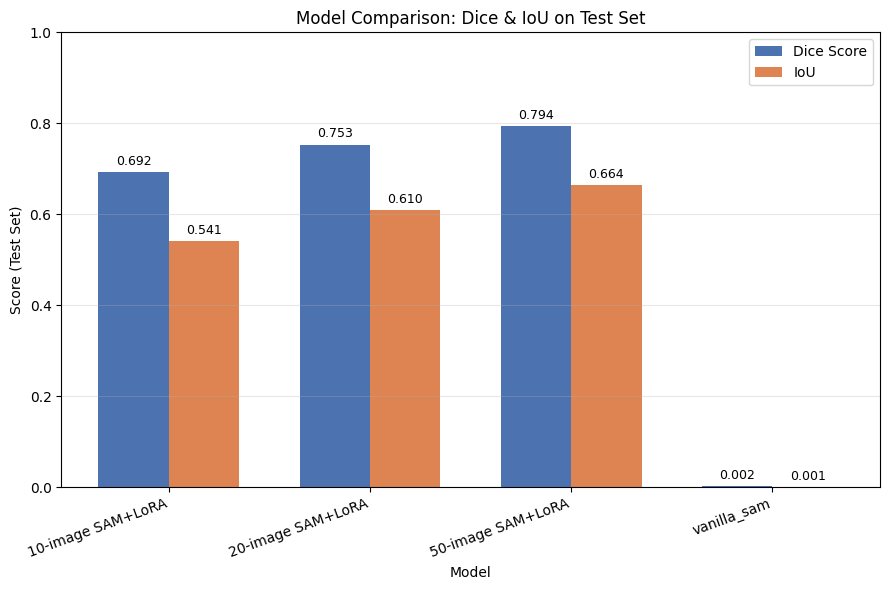

In [ ]:
##baseline comparision chart
##vanilla sam and sam+lora

import matplotlib.pyplot as plt
import numpy as np
import re

results_path = "/content/drive/MyDrive/sam-dental/all_results.txt"

with open(results_path) as f:
    lines = f.readlines()

models = []
dice_scores = []
iou_scores = []

for line in lines:
    line = line.strip()
    if not line:
        continue
    # Expected format: "LABEL | Dice: 0.XXXX +/- 0.XXXX | IoU: 0.XXXX +/- 0.XXXX"
    match = re.match(r"(.+?)\s*\|\s*Dice:\s*([\d.]+).*?\|\s*IoU:\s*([\d.]+)", line)
    if match:
        label = match.group(1).strip()
        dice = float(match.group(2))
        iou = float(match.group(3))
        models.append(label)
        dice_scores.append(dice)
        iou_scores.append(iou)

print("Parsed results:")
for m, d, i in zip(models, dice_scores, iou_scores):
    print(f"  {m}: Dice={d:.4f}, IoU={i:.4f}")

# Plot
x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(max(9, len(models)*2), 6))
bars1 = ax.bar(x - width/2, dice_scores, width, label='Dice Score', color='#4C72B0')
bars2 = ax.bar(x + width/2, iou_scores, width, label='IoU', color='#DD8452')

ax.set_xlabel('Model')
ax.set_ylabel('Score (Test Set)')
ax.set_title('Model Comparison: Dice & IoU on Test Set')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20, ha='right')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/sam-dental/baseline_comparison_chart.png", dpi=300)
plt.show()

In [ ]:
##U-NET part
# U-NET ARCHITECTURE
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, features=[64, 128, 256, 512]):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(2)

        for f in features:
            self.downs.append(DoubleConv(in_ch, f))
            in_ch = f

        self.bottleneck = DoubleConv(features[-1], features[-1]*2)

        for f in reversed(features):
            self.ups.append(nn.ConvTranspose2d(f*2, f, 2, stride=2))
            self.ups.append(DoubleConv(f*2, f))

        self.final_conv = nn.Conv2d(features[0], out_ch, 1)

    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skips = skips[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip = skips[idx // 2]
            if x.shape != skip.shape:
                x = nn.functional.interpolate(x, size=skip.shape[2:])
            x = torch.cat((skip, x), dim=1)
            x = self.ups[idx+1](x)

        return self.final_conv(x)

In [ ]:

# U-NET DATASET (full image + mask, no box prompt needed)

from torch.utils.data import Dataset
from PIL import Image
import numpy as np
import torchvision.transforms as T

UNET_SIZE = 256  # smaller resolution, U-Net doesn't need SAM's 1024

class UNetCariesDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs
        self.img_transform = T.Compose([
            T.Resize((UNET_SIZE, UNET_SIZE)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        item = self.pairs[idx]
        image = Image.open(item["image_path"]).convert("RGB")
        full_mask = polygon_to_mask(item["segmentation"], item["width"], item["height"])

        image_t = self.img_transform(image)

        mask_img = Image.fromarray(full_mask).resize((UNET_SIZE, UNET_SIZE), Image.NEAREST)
        mask_t = torch.tensor(np.array(mask_img), dtype=torch.float32).unsqueeze(0)

        return image_t, mask_t

In [ ]:

# U-NET TRAINING (for 10/20/50)
from torch.utils.data import DataLoader

UNET_SIZE_TRAIN = 50  # (for 10(done)/20(done)/50(done))

train_pairs_map = {10: train_pairs_10, 20: train_pairs_20, 50: train_pairs_50}
unet_train_pairs = train_pairs_map[UNET_SIZE_TRAIN]

unet_checkpoint_dir = f"/content/drive/MyDrive/sam-dental/unet_checkpoints_{UNET_SIZE_TRAIN}"
os.makedirs(unet_checkpoint_dir, exist_ok=True)
print(f"### TRAINING U-NET WITH {UNET_SIZE_TRAIN} IMAGES ###")

unet_model = UNet(in_ch=3, out_ch=1).to(device)
unet_dataset = UNetCariesDataset(unet_train_pairs)
unet_loader = DataLoader(unet_dataset, batch_size=4, shuffle=True)

optimizer = torch.optim.Adam(unet_model.parameters(), lr=1e-3)

NUM_EPOCHS = 50  # U-Net from scratch typically needs more epochs than fine-tuning
log_lines = []

for epoch in range(NUM_EPOCHS):
    unet_model.train()
    total_loss = 0
    for images, masks in unet_loader:
        images, masks = images.to(device), masks.to(device)

        preds = unet_model(images)
        loss = dice_loss(preds.squeeze(1), masks.squeeze(1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(unet_loader)
    log_line = f"Epoch {epoch+1} | Avg Dice Loss: {avg_loss:.4f}"
    if (epoch+1) % 5 == 0 or epoch == 0:
        print(log_line)
    log_lines.append(log_line)

torch.save(unet_model.state_dict(), f"{unet_checkpoint_dir}/unet_final.pth")
with open(f"/content/drive/MyDrive/sam-dental/unet_training_log_{UNET_SIZE_TRAIN}images.txt", "w") as f:
    f.write("\n".join(log_lines))

print(f"### DONE: U-Net ({UNET_SIZE_TRAIN} images) saved ###")

### TRAINING U-NET WITH 50 IMAGES ###


KeyboardInterrupt: 

In [ ]:
##U-NET Evaluation

def evaluate_unet(unet_model, test_pairs, device, threshold=0.5):
    unet_model.eval()
    dataset = UNetCariesDataset(test_pairs)
    dice_scores, iou_scores = [], []

    with torch.no_grad():
        for i in range(len(dataset)):
            image, gt_mask = dataset[i]
            image = image.unsqueeze(0).to(device)
            pred = torch.sigmoid(unet_model(image)).squeeze().cpu().numpy()

            pred_binary = (pred > threshold).astype(bool)
            gt_binary = (gt_mask.squeeze().numpy() > 0.5).astype(bool)

            dice_scores.append(dice_score_fn(pred_binary, gt_binary))
            iou_scores.append(iou_score_fn(pred_binary, gt_binary))

    return {
        "mean_dice": np.mean(dice_scores), "std_dice": np.std(dice_scores),
        "mean_iou": np.mean(iou_scores), "std_iou": np.std(iou_scores),
    }

UNET_EVAL_SIZE = 50 #(for 10(done),20(done),50)

unet_model_eval = UNet(in_ch=3, out_ch=1).to(device)
unet_model_eval.load_state_dict(torch.load(f"/content/drive/MyDrive/sam-dental/unet_checkpoints_{UNET_EVAL_SIZE}/unet_final.pth",map_location=device))

results = evaluate_unet(unet_model_eval, test_pairs, device)
print(f"\nU-Net ({UNET_EVAL_SIZE} images):")
print(f"  Mean Dice: {results['mean_dice']:.4f} (+/- {results['std_dice']:.4f})")
print(f"  Mean IoU:  {results['mean_iou']:.4f} (+/- {results['std_iou']:.4f})")

with open("/content/drive/MyDrive/sam-dental/all_results.txt", "a") as f:
    f.write(f"U-Net ({UNET_EVAL_SIZE} images) | Dice: {results['mean_dice']:.4f} +/- {results['std_dice']:.4f} | IoU: {results['mean_iou']:.4f} +/- {results['std_iou']:.4f}\n")


U-Net (50 images):
  Mean Dice: 0.0613 (+/- 0.1365)
  Mean IoU:  0.0379 (+/- 0.0900)


            Model  Mean Dice  Std Dice  Mean IoU  Std IoU
10-image SAM+LoRA     0.6921    0.1183    0.5406   0.1275
20-image SAM+LoRA     0.7534    0.0734    0.6097   0.0899
50-image SAM+LoRA     0.7938    0.0766    0.6644   0.0992
      vanilla_sam     0.0022    0.0154    0.0012   0.0083
U-Net (10 images)     0.0575    0.1426    0.0366   0.0962
U-Net (20 images)     0.0857    0.1534    0.0527   0.1000
U-Net (50 images)     0.0613    0.1365    0.0379   0.0900

Saved table to /content/drive/MyDrive/sam-dental/comparison_table.csv


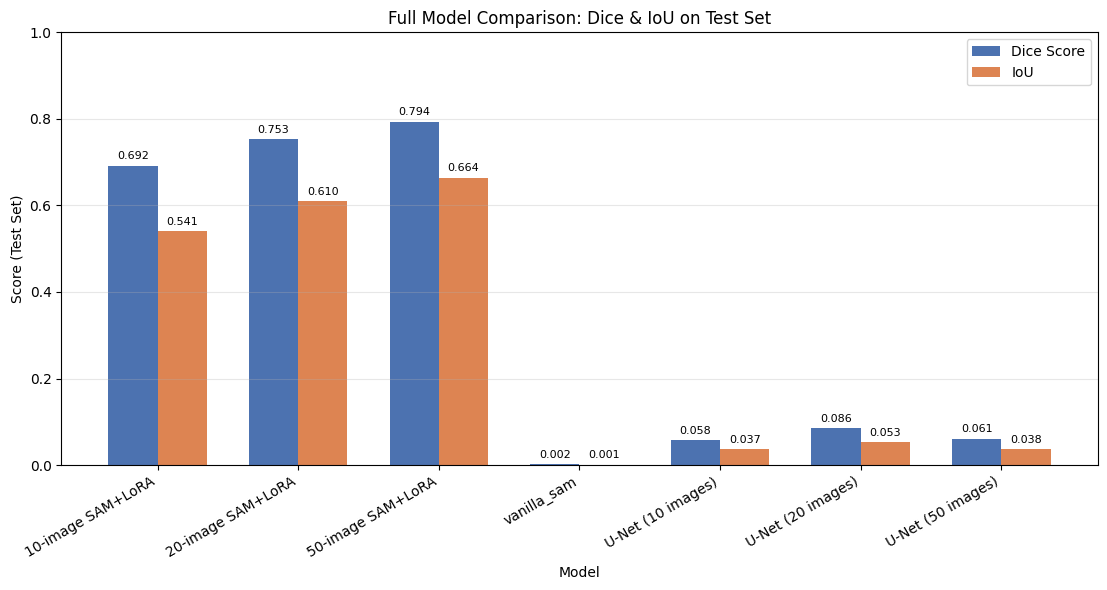

Saved chart to /content/drive/MyDrive/sam-dental/full_comparison_chart.png


In [ ]:
###charts
import re
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

results_path = "/content/drive/MyDrive/sam-dental/all_results.txt"

with open(results_path) as f:
    lines = f.readlines()

records = []
for line in lines:
    line = line.strip()
    if not line:
        continue
    match = re.match(r"(.+?)\s*\|\s*Dice:\s*([\d.]+)\s*\+/-\s*([\d.]+)\s*\|\s*IoU:\s*([\d.]+)\s*\+/-\s*([\d.]+)", line)
    if match:
        records.append({
            "Model": match.group(1).strip(),
            "Mean Dice": float(match.group(2)),
            "Std Dice": float(match.group(3)),
            "Mean IoU": float(match.group(4)),
            "Std IoU": float(match.group(5)),
        })

df = pd.DataFrame(records)
print(df.to_string(index=False))

# Save as CSV for the paper / supplementary table
csv_path = "/content/drive/MyDrive/sam-dental/comparison_table.csv"
df.to_csv(csv_path, index=False)
print(f"\nSaved table to {csv_path}")

# === CHART: full comparison bar chart ===
models = df["Model"].tolist()
dice_scores = df["Mean Dice"].tolist()
iou_scores = df["Mean IoU"].tolist()

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(max(10, len(models)*1.6), 6))
bars1 = ax.bar(x - width/2, dice_scores, width, label='Dice Score', color='#4C72B0')
bars2 = ax.bar(x + width/2, iou_scores, width, label='IoU', color='#DD8452')

ax.set_xlabel('Model')
ax.set_ylabel('Score (Test Set)')
ax.set_title('Full Model Comparison: Dice & IoU on Test Set')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30, ha='right')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
chart_path = "/content/drive/MyDrive/sam-dental/full_comparison_chart.png"
plt.savefig(chart_path, dpi=300)
plt.show()
print(f"Saved chart to {chart_path}")

                       Model  Mean Dice  Std Dice  Mean IoU  Std IoU
           10-image SAM+LoRA     0.6921    0.1183    0.5406   0.1275
           20-image SAM+LoRA     0.7534    0.0734    0.6097   0.0899
           50-image SAM+LoRA     0.7938    0.0766    0.6644   0.0992
                 vanilla_sam     0.0022    0.0154    0.0012   0.0083
           U-Net (10 images)     0.0575    0.1426    0.0366   0.0962
           U-Net (20 images)     0.0857    0.1534    0.0527   0.1000
           U-Net (50 images)     0.0613    0.1365    0.0379   0.0900
Full Fine-Tuning (10 images)     0.6836    0.1094    0.5293   0.1214
Full Fine-Tuning (20 images)     0.7414    0.0948    0.5975   0.1118
Full Fine-Tuning (50 images)     0.7715    0.0823    0.6348   0.1011
          MedSAM (zero-shot)     0.0018    0.0125    0.0009   0.0066

Saved table to /content/drive/MyDrive/sam-dental/comparison_table1.csv


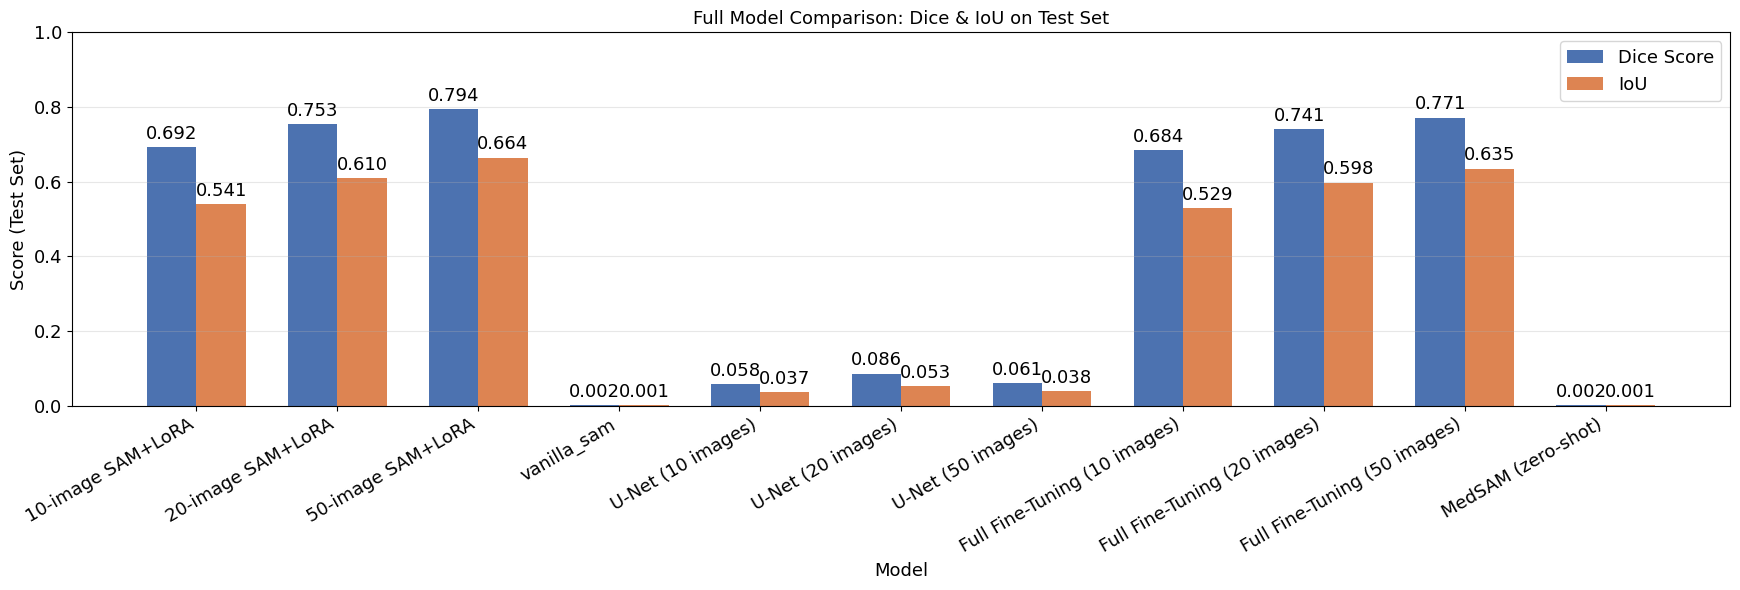

Saved chart to /content/drive/MyDrive/sam-dental/full_comparison_chart1.png


In [ ]:
###charts
import re
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

results_path = "/content/drive/MyDrive/sam-dental/all_results.txt"

with open(results_path) as f:
    lines = f.readlines()

records = []
for line in lines:
    line = line.strip()
    if not line:
        continue
    match = re.match(r"(.+?)\s*\|\s*Dice:\s*([\d.]+)\s*\+/-\s*([\d.]+)\s*\|\s*IoU:\s*([\d.]+)\s*\+/-\s*([\d.]+)", line)
    if match:
        records.append({
            "Model": match.group(1).strip(),
            "Mean Dice": float(match.group(2)),
            "Std Dice": float(match.group(3)),
            "Mean IoU": float(match.group(4)),
            "Std IoU": float(match.group(5)),
        })

df = pd.DataFrame(records)
print(df.to_string(index=False))

# Save as CSV for the paper / supplementary table
csv_path = "/content/drive/MyDrive/sam-dental/comparison_table1.csv"
df.to_csv(csv_path, index=False)
print(f"\nSaved table to {csv_path}")

# === CHART: full comparison bar chart ===
models = df["Model"].tolist()
dice_scores = df["Mean Dice"].tolist()
iou_scores = df["Mean IoU"].tolist()

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(max(10, len(models)*1.6), 6))
bars1 = ax.bar(x - width/2, dice_scores, width, label='Dice Score', color='#4C72B0')
bars2 = ax.bar(x + width/2, iou_scores, width, label='IoU', color='#DD8452')

ax.set_xlabel('Model', fontsize=13)
ax.set_ylabel('Score (Test Set)', fontsize=13)
ax.set_title('Full Model Comparison: Dice & IoU on Test Set', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30, ha='right', fontsize=13)
ax.tick_params(axis='y', labelsize=13)
ax.set_ylim(0, 1)
ax.legend(fontsize=13)
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=13)

plt.tight_layout()
chart_path = "/content/drive/MyDrive/sam-dental/full_comparison_chart1.png"
plt.savefig(chart_path, dpi=300)
plt.show()
print(f"Saved chart to {chart_path}")

SAM rows (sorted):
               Model  Mean Dice  Std Dice  Mean IoU  Std IoU
0  10-image SAM+LoRA     0.6921    0.1183    0.5406   0.1275
1  20-image SAM+LoRA     0.7534    0.0734    0.6097   0.0899
2  50-image SAM+LoRA     0.7938    0.0766    0.6644   0.0992

U-Net rows (sorted):
               Model  Mean Dice  Std Dice  Mean IoU  Std IoU
4  U-Net (10 images)     0.0575    0.1426    0.0366   0.0962
5  U-Net (20 images)     0.0857    0.1534    0.0527   0.1000
6  U-Net (50 images)     0.0613    0.1365    0.0379   0.0900


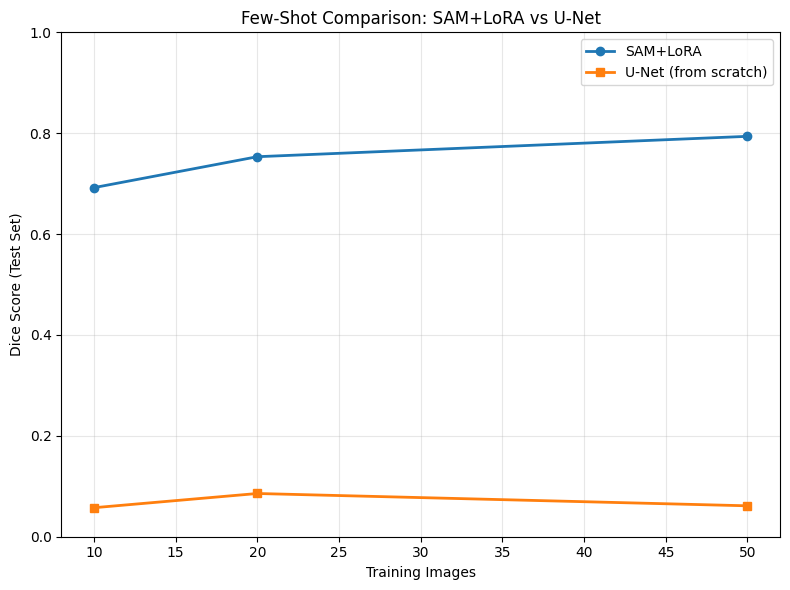

Saved to /content/drive/MyDrive/sam-dental/fewshot_sam_vs_unet.png


In [ ]:
SAM+LORA VS U-net

import matplotlib.pyplot as plt

fewshot_df = df[df["Model"].str.contains("image", case=False)]

sam_rows = fewshot_df[fewshot_df["Model"].str.contains("SAM", case=False)].sort_values("Model")
unet_rows = fewshot_df[fewshot_df["Model"].str.contains("U-Net", case=False)].sort_values("Model")

print("SAM rows (sorted):")
print(sam_rows)
print("\nU-Net rows (sorted):")
print(unet_rows)

plt.figure(figsize=(8, 6))
plt.plot([10, 20, 50], sam_rows["Mean Dice"].values, marker='o', linewidth=2, label='SAM+LoRA')
plt.plot([10, 20, 50], unet_rows["Mean Dice"].values, marker='s', linewidth=2, label='U-Net (from scratch)')
plt.xlabel("Training Images")
plt.ylabel("Dice Score (Test Set)")
plt.title("Few-Shot Comparison: SAM+LoRA vs U-Net")
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(0, 1)
plt.tight_layout()

save_path = "/content/drive/MyDrive/sam-dental/fewshot_sam_vs_unet.png"
plt.savefig(save_path, dpi=300)
plt.show()
print(f"Saved to {save_path}")

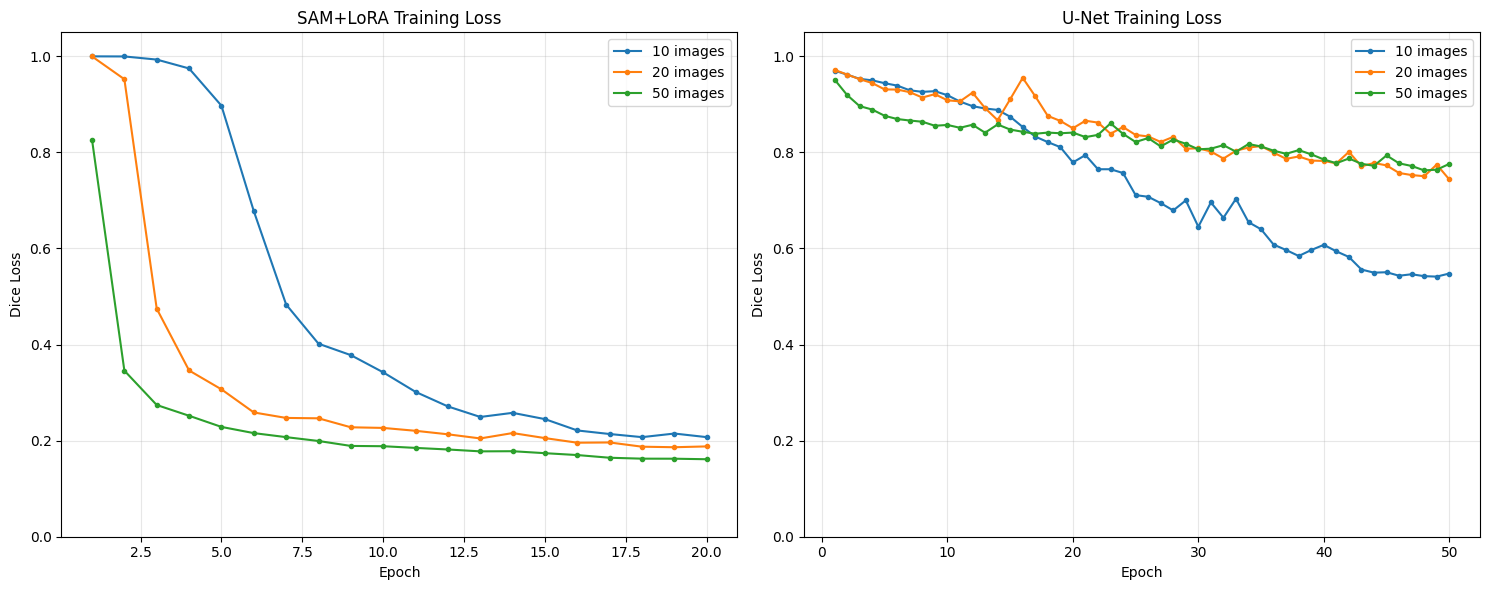

Saved to /content/drive/MyDrive/sam-dental/training_curves_comparison.png


In [ ]:
### sam+lora loss and u-net loss
import re
import matplotlib.pyplot as plt

def parse_log_text(log_text):
    """Extract epoch numbers and loss values from a training log string."""
    epochs = []
    losses = []
    for match in re.finditer(r"Epoch (\d+)\s*\|\s*Avg Dice Loss:\s*([\d.]+)", log_text):
        epochs.append(int(match.group(1)))
        losses.append(float(match.group(2)))
    return epochs, losses

def parse_log_file(filepath):
    with open(filepath) as f:
        return parse_log_text(f.read())

# === Load SAM+LoRA training logs ===
epochs_10, loss_10 = parse_log_file("/content/drive/MyDrive/sam-dental/training_log_10images.txt")
epochs_20, loss_20 = parse_log_file("/content/drive/MyDrive/sam-dental/training_log_20images.txt")
epochs_50, loss_50 = parse_log_file("/content/drive/MyDrive/sam-dental/training_log_50images.txt")

# === Load U-Net training logs ===
u_epochs_10, u_loss_10 = parse_log_file("/content/drive/MyDrive/sam-dental/unet_training_log_10images.txt")
u_epochs_20, u_loss_20 = parse_log_file("/content/drive/MyDrive/sam-dental/unet_training_log_20images.txt")
u_epochs_50, u_loss_50 = parse_log_file("/content/drive/MyDrive/sam-dental/unet_training_log_50images.txt")

# === Plot: two panels side by side (SAM+LoRA vs U-Net) ===
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].plot(epochs_10, loss_10, label="10 images", marker='o', markersize=3)
axes[0].plot(epochs_20, loss_20, label="20 images", marker='o', markersize=3)
axes[0].plot(epochs_50, loss_50, label="50 images", marker='o', markersize=3)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Dice Loss")
axes[0].set_title("SAM+LoRA Training Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1.05)

axes[1].plot(u_epochs_10, u_loss_10, label="10 images", marker='o', markersize=3)
axes[1].plot(u_epochs_20, u_loss_20, label="20 images", marker='o', markersize=3)
axes[1].plot(u_epochs_50, u_loss_50, label="50 images", marker='o', markersize=3)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Dice Loss")
axes[1].set_title("U-Net Training Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
save_path = "/content/drive/MyDrive/sam-dental/training_curves_comparison.png"
plt.savefig(save_path, dpi=300)
plt.show()
print(f"Saved to {save_path}")

In [ ]:
### mc dropout uncertanity estimation
import torch
import numpy as np
import matplotlib.pyplot as plt
import pickle
from transformers import AutoModelForMaskGeneration
from peft import PeftModel

device = "cuda" if torch.cuda.is_available() else "cpu"

base_model = AutoModelForMaskGeneration.from_pretrained("facebook/sam-vit-base")
mc_model = PeftModel.from_pretrained(base_model, "/content/drive/MyDrive/sam-dental/checkpoints_50/epoch_20")
mc_model.to(device)

def enable_dropout(model):
    for module in model.modules():
        if module.__class__.__name__.startswith('Dropout'):
            module.train()

def mc_dropout_predict(model, inputs, gt_shape, n_passes=25):
    model.eval()
    enable_dropout(model)
    predictions = []
    with torch.no_grad():
        for _ in range(n_passes):
            outputs = model(**inputs)
            pred_mask = outputs.pred_masks[:, :, 0]
            pred_mask = F.interpolate(pred_mask, size=gt_shape, mode="bilinear", align_corners=False)
            pred_mask = torch.sigmoid(pred_mask).squeeze().cpu().numpy()
            predictions.append(pred_mask)
    predictions = np.stack(predictions, axis=0)
    mean_pred = predictions.mean(axis=0)
    uncertainty = predictions.var(axis=0)
    return mean_pred, uncertainty

# === Run on ALL test samples (not just 4) so you have full data for later analysis ===
test_dataset = CariesDataset(test_pairs, processor, train=False)

all_results = []  # will store everything for every test sample

for i in range(len(test_pairs)):
    item = test_pairs[i]
    batch = test_dataset[i]
    gt_mask = batch.pop("gt_mask").numpy()
    inputs = {k: v.unsqueeze(0).to(device) for k, v in batch.items()}

    mean_pred, uncertainty = mc_dropout_predict(mc_model, inputs, gt_mask.shape, n_passes=25)

    all_results.append({
        "image_path": item["image_path"],
        "image_id": item["image_id"],
        "gt_mask": gt_mask,
        "mean_pred": mean_pred,
        "uncertainty": uncertainty,
    })

    if (i+1) % 20 == 0:
        print(f"Processed {i+1}/{len(test_pairs)}")

# Save everything to disk - this is your raw data for any future graph/analysis
save_data_path = "/content/drive/MyDrive/sam-dental/mc_dropout_results.pkl"
with open(save_data_path, "wb") as f:
    pickle.dump(all_results, f)
print(f"Saved all MC Dropout results to {save_data_path}")

# === Visualize just the first 4 examples (as before) ===
num_examples = 4
fig, axes = plt.subplots(num_examples, 4, figsize=(16, 4*num_examples))

for i in range(num_examples):
    r = all_results[i]
    image = Image.open(r["image_path"]).convert("RGB")
    image.thumbnail((1024, 1024), Image.LANCZOS)
    image_arr = np.array(image)

    axes[i, 0].imshow(image_arr)
    axes[i, 0].set_title("Original X-ray")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(r["gt_mask"], cmap="gray")
    axes[i, 1].set_title("Ground Truth")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(r["mean_pred"], cmap="gray")
    axes[i, 2].set_title("Mean Prediction (MC)")
    axes[i, 2].axis("off")

    im = axes[i, 3].imshow(r["uncertainty"], cmap="hot")
    axes[i, 3].set_title("Uncertainty (variance)")
    axes[i, 3].axis("off")
    plt.colorbar(im, ax=axes[i, 3], fraction=0.046)

plt.tight_layout()
chart_path = "/content/drive/MyDrive/sam-dental/mc_dropout_uncertainty.png"
plt.savefig(chart_path, dpi=200)
plt.show()
print(f"Saved visualization to {chart_path}")

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

In [ ]:
##first 15 image
## 10 passes
from tqdm import tqdm
import pickle

test_pairs_mc = test_pairs[:15]   # small enough for CPU
n_passes = 10                      # reduced from 25, still gives a reasonable variance estimate

all_results = []

for i in tqdm(range(len(test_pairs_mc)), desc="MC Dropout (CPU, reduced)"):
    item = test_pairs_mc[i]
    batch = test_dataset[i]
    gt_mask = batch.pop("gt_mask").numpy()
    inputs = {k: v.unsqueeze(0).to(device) for k, v in batch.items()}

    mean_pred, uncertainty = mc_dropout_predict(mc_model, inputs, gt_mask.shape, n_passes=n_passes)

    all_results.append({
        "image_path": item["image_path"],
        "image_id": item["image_id"],
        "gt_mask": gt_mask,
        "mean_pred": mean_pred,
        "uncertainty": uncertainty,
    })

save_data_path = "/content/drive/MyDrive/sam-dental/mc_dropout_results_small.pkl"
with open(save_data_path, "wb") as f:
    pickle.dump(all_results, f)
print(f"Saved to {save_data_path}")

MC Dropout (CPU, reduced): 100%|██████████| 15/15 [47:20<00:00, 189.39s/it]

Saved to /content/drive/MyDrive/sam-dental/mc_dropout_results_small.pkl


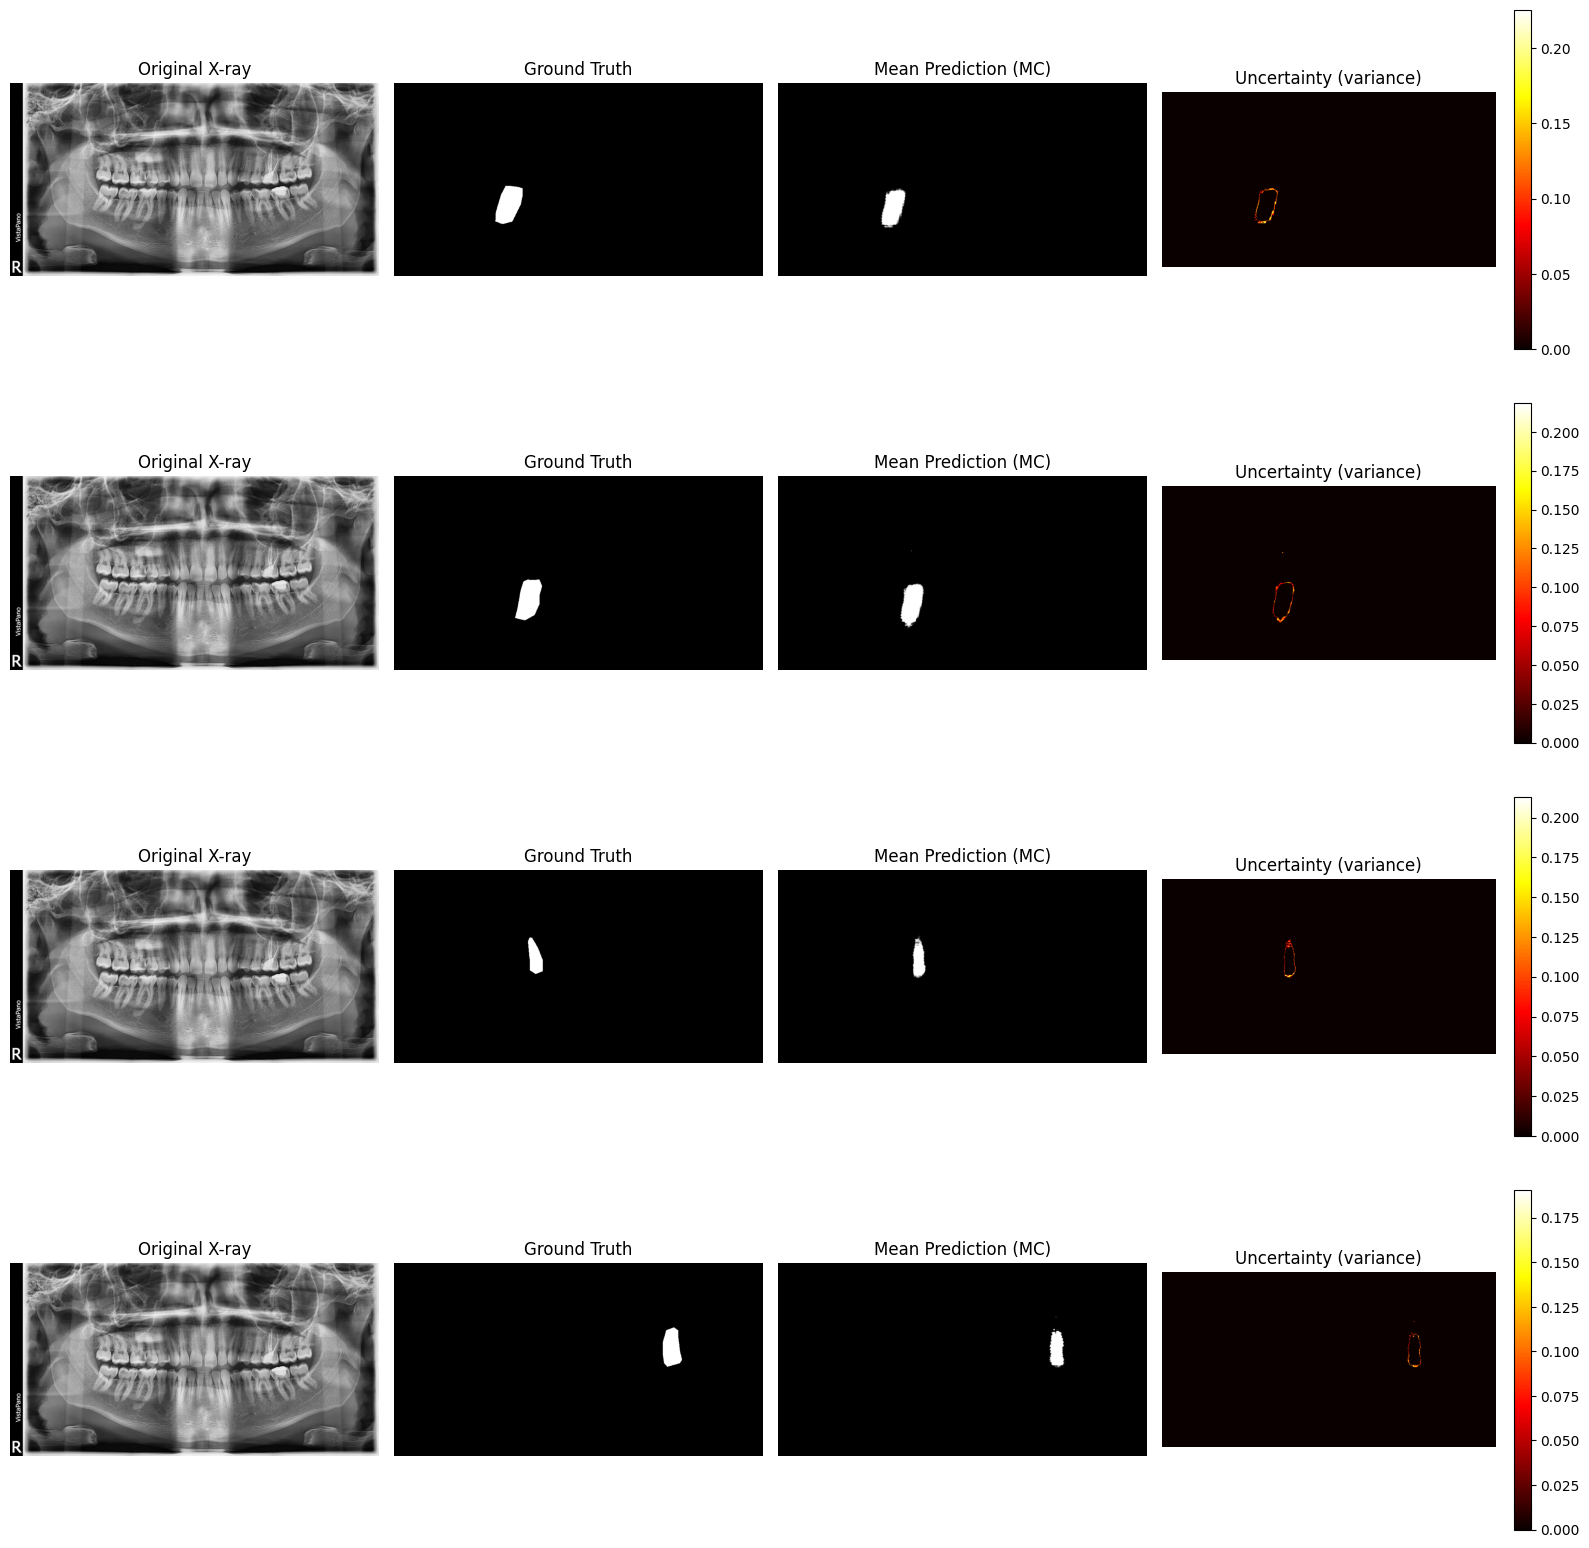

Saved to /content/drive/MyDrive/sam-dental/mc_dropout_uncertainty.png


In [ ]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

with open("/content/drive/MyDrive/sam-dental/mc_dropout_results_small.pkl", "rb") as f:
    all_results = pickle.load(f)

num_examples = min(4, len(all_results))
fig, axes = plt.subplots(num_examples, 4, figsize=(16, 4*num_examples))

for i in range(num_examples):
    r = all_results[i]
    image = Image.open(r["image_path"]).convert("RGB")
    image.thumbnail((1024, 1024), Image.LANCZOS)
    image_arr = np.array(image)

    axes[i, 0].imshow(image_arr)
    axes[i, 0].set_title("Original X-ray")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(r["gt_mask"], cmap="gray")
    axes[i, 1].set_title("Ground Truth")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(r["mean_pred"], cmap="gray")
    axes[i, 2].set_title("Mean Prediction (MC)")
    axes[i, 2].axis("off")

    im = axes[i, 3].imshow(r["uncertainty"], cmap="hot")
    axes[i, 3].set_title("Uncertainty (variance)")
    axes[i, 3].axis("off")
    plt.colorbar(im, ax=axes[i, 3], fraction=0.046)

plt.tight_layout()
chart_path = "/content/drive/MyDrive/sam-dental/mc_dropout_uncertainty.png"
plt.savefig(chart_path, dpi=200)
plt.show()
print(f"Saved to {chart_path}")

=== POOLED RESULTS (all samples combined) ===
Pearson correlation (uncertainty vs error): 0.2965 (p=0.00e+00)
Mean uncertainty at INCORRECT pixels: 0.020132
Mean uncertainty at CORRECT pixels:   0.000070
Ratio (error/correct): 288.18x

=== PER-SAMPLE STATS ===
 image_id  pearson_corr  p_value  mean_uncertainty_error_pixels  mean_uncertainty_correct_pixels  error_pixel_count
       16      0.387785      0.0                       0.035191                         0.000090               1730
       16      0.324911      0.0                       0.023947                         0.000084               1737
       16      0.376285      0.0                       0.029096                         0.000055               1055
       16      0.264995      0.0                       0.014931                         0.000047               1488
       16      0.392669      0.0                       0.034675                         0.000097               1361
       16      0.319551      0.0           

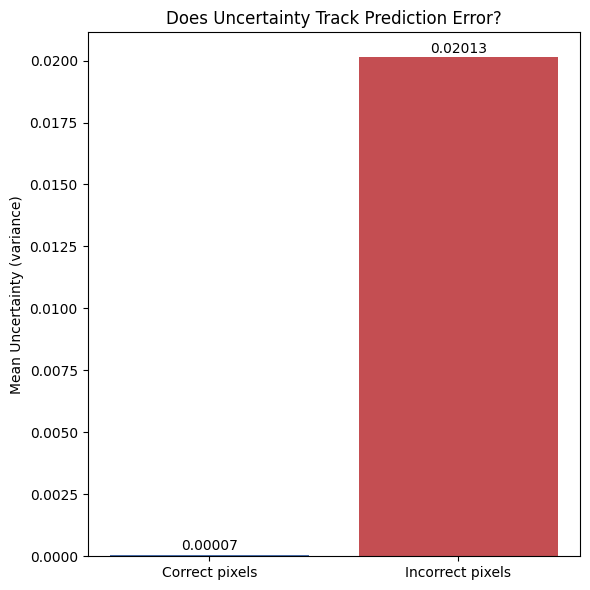

Saved chart to /content/drive/MyDrive/sam-dental/uncertainty_vs_error_chart.png


In [ ]:
import pickle
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# Load your MC Dropout results
with open("/content/drive/MyDrive/sam-dental/mc_dropout_results_small.pkl", "rb") as f:
    all_results = pickle.load(f)

per_sample_stats = []
all_uncertainty_flat = []
all_error_flat = []

for idx, r in enumerate(all_results):
    gt = (r["gt_mask"] > 0.5).astype(np.uint8)
    pred_binary = (r["mean_pred"] > 0.5).astype(np.uint8)
    uncertainty = r["uncertainty"]

    # Error map: 1 where prediction disagrees with ground truth, 0 where correct
    error_map = (pred_binary != gt).astype(np.uint8)

    # Flatten for correlation
    unc_flat = uncertainty.flatten()
    err_flat = error_map.flatten()

    # Per-sample Pearson correlation between uncertainty and error
    if err_flat.sum() > 0 and err_flat.sum() < len(err_flat):  # avoid degenerate all-0 or all-1 cases
        corr, pval = pearsonr(unc_flat, err_flat)
    else:
        corr, pval = np.nan, np.nan

    # Mean uncertainty in error vs correct regions - simple, interpretable stat
    mean_unc_error_pixels = uncertainty[error_map == 1].mean() if error_map.sum() > 0 else np.nan
    mean_unc_correct_pixels = uncertainty[error_map == 0].mean()

    per_sample_stats.append({
        "image_id": r["image_id"],
        "pearson_corr": corr,
        "p_value": pval,
        "mean_uncertainty_error_pixels": mean_unc_error_pixels,
        "mean_uncertainty_correct_pixels": mean_unc_correct_pixels,
        "error_pixel_count": int(error_map.sum()),
    })

    all_uncertainty_flat.append(unc_flat)
    all_error_flat.append(err_flat)

# === Aggregate across ALL samples combined (pooled pixels) ===
pooled_unc = np.concatenate(all_uncertainty_flat)
pooled_err = np.concatenate(all_error_flat)
pooled_corr, pooled_pval = pearsonr(pooled_unc, pooled_err)

pooled_mean_unc_error = pooled_unc[pooled_err == 1].mean()
pooled_mean_unc_correct = pooled_unc[pooled_err == 0].mean()

print("=== POOLED RESULTS (all samples combined) ===")
print(f"Pearson correlation (uncertainty vs error): {pooled_corr:.4f} (p={pooled_pval:.2e})")
print(f"Mean uncertainty at INCORRECT pixels: {pooled_mean_unc_error:.6f}")
print(f"Mean uncertainty at CORRECT pixels:   {pooled_mean_unc_correct:.6f}")
print(f"Ratio (error/correct): {pooled_mean_unc_error/pooled_mean_unc_correct:.2f}x")

# === Per-sample table ===
df_stats = pd.DataFrame(per_sample_stats)
print("\n=== PER-SAMPLE STATS ===")
print(df_stats.to_string(index=False))

# Save everything for future comparison/paper writing
save_csv_path = "/content/drive/MyDrive/sam-dental/uncertainty_error_correlation.csv"
df_stats.to_csv(save_csv_path, index=False)

pooled_summary = {
    "pooled_pearson_corr": pooled_corr,
    "pooled_p_value": pooled_pval,
    "pooled_mean_uncertainty_error_pixels": pooled_mean_unc_error,
    "pooled_mean_uncertainty_correct_pixels": pooled_mean_unc_correct,
    "ratio_error_to_correct": pooled_mean_unc_error/pooled_mean_unc_correct,
}
with open("/content/drive/MyDrive/sam-dental/uncertainty_error_pooled_summary.pkl", "wb") as f:
    pickle.dump(pooled_summary, f)

print(f"\nSaved per-sample stats to {save_csv_path}")
print(f"Saved pooled summary to uncertainty_error_pooled_summary.pkl")

# === Visualization: bar chart comparing mean uncertainty in error vs correct regions ===
plt.figure(figsize=(6, 6))
bars = plt.bar(["Correct pixels", "Incorrect pixels"],
                [pooled_mean_unc_correct, pooled_mean_unc_error],
                color=["#4C72B0", "#C44E52"])
plt.ylabel("Mean Uncertainty (variance)")
plt.title("Does Uncertainty Track Prediction Error?")
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.5f}', xy=(bar.get_x() + bar.get_width()/2, height),
                 xytext=(0, 3), textcoords="offset points", ha='center', fontsize=10)
plt.tight_layout()

chart_path = "/content/drive/MyDrive/sam-dental/uncertainty_vs_error_chart.png"
plt.savefig(chart_path, dpi=300)
plt.show()
print(f"Saved chart to {chart_path}")

In [ ]:
##full fine tuning (no-lora)
##training
import torch, os, gc
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm
from transformers import AutoModelForMaskGeneration

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

FEWSHOT_SIZE = 50   # <-- change to 10(done), 20(done), or 50(done) each run

train_pairs_map = {10: train_pairs_10, 20: train_pairs_20, 50: train_pairs_50}
train_pairs_current = train_pairs_map[FEWSHOT_SIZE]

checkpoint_dir = f"/content/drive/MyDrive/sam-dental/fullft_checkpoints_{FEWSHOT_SIZE}"
os.makedirs(checkpoint_dir, exist_ok=True)
print(f"### FULL FINE-TUNING WITH {FEWSHOT_SIZE} IMAGES — SAVING TO: {checkpoint_dir} ###")

# Fresh model, NO LoRA wrapping - every parameter is trainable
model = AutoModelForMaskGeneration.from_pretrained("facebook/sam-vit-base")
model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,} | Trainable params: {trainable_params:,} "
      f"| Trainable %: {100*trainable_params/total_params:.4f}%")

with open(f"/content/drive/MyDrive/sam-dental/fullft_param_info_{FEWSHOT_SIZE}.txt", "w") as f:
    f.write(f"method: full_finetuning\n")
    f.write(f"fewshot_size: {FEWSHOT_SIZE}\n")
    f.write(f"total_params: {total_params}\n")
    f.write(f"trainable_params: {trainable_params}\n")

    f.write(f"trainable_percent: {100*trainable_params/total_params:.4f}\n")

train_dataset = CariesDataset(train_pairs_current, processor, train=True)
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, collate_fn=collate_fn)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)

NUM_EPOCHS = 20
log_lines = []

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc=f"[FullFT-{FEWSHOT_SIZE}img] Epoch {epoch+1}"):
        gt_mask = batch.pop("gt_mask").to(device)
        inputs = {k: v.unsqueeze(0).to(device) for k, v in batch.items()}

        outputs = model(**inputs)
        pred_mask = outputs.pred_masks[:, :, 0]
        pred_mask = F.interpolate(pred_mask, size=gt_mask.shape[-2:], mode="bilinear", align_corners=False)
        pred_mask = pred_mask.squeeze()

        loss = dice_loss(pred_mask, gt_mask)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        del outputs, pred_mask, loss, inputs, gt_mask
        gc.collect()
        torch.cuda.empty_cache()

    avg_loss = total_loss / len(train_loader)
    log_line = f"Epoch {epoch+1} | Avg Dice Loss: {avg_loss:.4f}"
    print(log_line)
    log_lines.append(log_line)

    # Only save weights on the FINAL epoch - saves ~19x storage vs saving every epoch
    if epoch == NUM_EPOCHS - 1:
        model.save_pretrained(f"{checkpoint_dir}/epoch_{epoch+1}")
        print(f"  -> Saved final checkpoint at epoch {epoch+1}")

with open(f"/content/drive/MyDrive/sam-dental/fullft_training_log_{FEWSHOT_SIZE}images.txt", "w") as f:
    f.write("\n".join(log_lines))

print(f"### DONE: Full fine-tuning ({FEWSHOT_SIZE} images) saved to {checkpoint_dir} ###")

Device: cuda
### FULL FINE-TUNING WITH 50 IMAGES — SAVING TO: /content/drive/MyDrive/sam-dental/fullft_checkpoints_50 ###


Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

Total params: 93,735,728 | Trainable params: 93,735,728 | Trainable %: 100.0000%


[FullFT-50img] Epoch 1: 100%|██████████| 178/178 [06:26<00:00,  2.17s/it]


Epoch 1 | Avg Dice Loss: 0.4968


...

Epoch 19 | Avg Dice Loss: 0.1082


[FullFT-50img] Epoch 20: 100%|██████████| 178/178 [05:48<00:00,  1.96s/it]


Epoch 20 | Avg Dice Loss: 0.1096


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  -> Saved final checkpoint at epoch 20
### DONE: Full fine-tuning (50 images) saved to /content/drive/MyDrive/sam-dental/fullft_checkpoints_50 ###


In [ ]:

# FULL FINE-TUNING EVALUATION CELL
from transformers import AutoModelForMaskGeneration

EVAL_SIZE = 50   # <-- change to 10(done), 20(done), or 50

checkpoint_path = f"/content/drive/MyDrive/sam-dental/fullft_checkpoints_{EVAL_SIZE}/epoch_20"
print(f"### EVALUATING FULL FINE-TUNED {EVAL_SIZE}-IMAGE MODEL FROM: {checkpoint_path} ###")

eval_model = AutoModelForMaskGeneration.from_pretrained(checkpoint_path)
eval_model.to(device)

results = evaluate_model(eval_model, test_pairs, processor, device)

print(f"\nFull Fine-Tuning ({EVAL_SIZE} images):")
print(f"  Mean Dice: {results['mean_dice']:.4f} (+/- {results['std_dice']:.4f})")
print(f"  Mean IoU:  {results['mean_iou']:.4f} (+/- {results['std_iou']:.4f})")

with open("/content/drive/MyDrive/sam-dental/all_results.txt", "a") as f:
    f.write(f"Full Fine-Tuning ({EVAL_SIZE} images) | Dice: {results['mean_dice']:.4f} +/- {results['std_dice']:.4f} | IoU: {results['mean_iou']:.4f} +/- {results['std_iou']:.4f}\n")

### EVALUATING FULL FINE-TUNED 50-IMAGE MODEL FROM: /content/drive/MyDrive/sam-dental/fullft_checkpoints_50/epoch_20 ###


Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

Evaluating: 100%|██████████| 171/171 [02:37<00:00,  1.08it/s]



Full Fine-Tuning (50 images):
  Mean Dice: 0.7715 (+/- 0.0823)
  Mean IoU:  0.6348 (+/- 0.1011)


In [ ]:
with open("/content/drive/MyDrive/sam-dental/all_results.txt") as f:
    print(f.read())

10-image SAM+LoRA | Dice: 0.6921 +/- 0.1183 | IoU: 0.5406 +/- 0.1275
20-image SAM+LoRA | Dice: 0.7534 +/- 0.0734 | IoU: 0.6097 +/- 0.0899
50-image SAM+LoRA | Dice: 0.7938 +/- 0.0766 | IoU: 0.6644 +/- 0.0992
vanilla_sam | Dice: 0.0022 +/- 0.0154 | IoU: 0.0012 +/- 0.0083
U-Net (10 images) | Dice: 0.0575 +/- 0.1426 | IoU: 0.0366 +/- 0.0962
U-Net (20 images) | Dice: 0.0857 +/- 0.1534 | IoU: 0.0527 +/- 0.1000
U-Net (50 images) | Dice: 0.0613 +/- 0.1365 | IoU: 0.0379 +/- 0.0900
Full Fine-Tuning (10 images) | Dice: 0.6836 +/- 0.1094 | IoU: 0.5293 +/- 0.1214
Full Fine-Tuning (20 images) | Dice: 0.7414 +/- 0.0948 | IoU: 0.5975 +/- 0.1118
Full Fine-Tuning (50 images) | Dice: 0.7715 +/- 0.0823 | IoU: 0.6348 +/- 0.1011



In [ ]:
# ============================================================
# FULL SELF-CONTAINED MEDSAM EVALUATION
# ============================================================
import json, os, random
import numpy as np
from PIL import Image, ImageDraw
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset
from tqdm import tqdm
from transformers import SamModel, SamProcessor
from google.colab import drive

drive.mount('/content/drive')
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
MAX_SIZE = 1024

# ---- Rebuild test_pairs ----
json_path = "/content/drive/MyDrive/dentex_train/training_data/quadrant-enumeration-disease/train_quadrant_enumeration_disease.json"
with open(json_path) as f:
    data = json.load(f)

caries_annotations = [ann for ann in data["annotations"] if ann["category_id_3"] == 1]
image_lookup = {img["id"]: img for img in data["images"]}
image_dir = "/content/drive/MyDrive/dentex_train/training_data/quadrant-enumeration-disease/xrays"

dataset_pairs = []
for ann in caries_annotations:
    img_info = image_lookup[ann["image_id"]]
    image_path = os.path.join(image_dir, img_info["file_name"])
    if not os.path.exists(image_path):
        continue
    dataset_pairs.append({
        "image_path": image_path, "segmentation": ann["segmentation"],
        "box": ann["bbox"], "image_id": ann["image_id"],
        "width": img_info["width"], "height": img_info["height"],
    })

unique_images = set(p["image_id"] for p in dataset_pairs)
random.seed(42)
unique_image_ids = list(unique_images)
random.shuffle(unique_image_ids)
selected_ids = unique_image_ids[:100]
test_ids = set(selected_ids[50:100])
test_pairs = [p for p in dataset_pairs if p["image_id"] in test_ids]
print(f"test_pairs: {len(test_pairs)} samples")

# ---- Helpers ----
def polygon_to_mask(segmentation, width, height):
    mask = Image.new("L", (width, height), 0)
    for poly in segmentation:
        points = [(poly[i], poly[i+1]) for i in range(0, len(poly), 2)]
        ImageDraw.Draw(mask).polygon(points, outline=1, fill=1)
    return np.array(mask)

class CariesDataset(Dataset):
    def __init__(self, pairs, processor, train=True):
        self.pairs = pairs
        self.processor = processor
        self.train = train
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, idx):
        item = self.pairs[idx]
        image = Image.open(item["image_path"]).convert("RGB")
        orig_w, orig_h = image.size
        full_mask = polygon_to_mask(item["segmentation"], item["width"], item["height"])
        image.thumbnail((MAX_SIZE, MAX_SIZE), Image.LANCZOS)
        new_w, new_h = image.size
        scale_x, scale_y = new_w / orig_w, new_h / orig_h
        mask_img = Image.fromarray(full_mask).resize((new_w, new_h), Image.NEAREST)
        mask = np.array(mask_img).astype(np.float32)
        box = item["box"]
        scaled_box = [box[0]*scale_x, box[1]*scale_y, box[2]*scale_x, box[3]*scale_y]
        box_xyxy = [scaled_box[0], scaled_box[1], scaled_box[0]+scaled_box[2], scaled_box[1]+scaled_box[3]]
        inputs = self.processor(image, input_boxes=[[box_xyxy]], return_tensors="pt")
        inputs = {k: v.squeeze(0) for k, v in inputs.items()}
        inputs["gt_mask"] = torch.tensor(mask)
        return inputs

def dice_score_fn(pred_binary, gt_binary, eps=1e-6):
    intersection = (pred_binary & gt_binary).sum()
    return (2 * intersection + eps) / (pred_binary.sum() + gt_binary.sum() + eps)

def iou_score_fn(pred_binary, gt_binary, eps=1e-6):
    intersection = (pred_binary & gt_binary).sum()
    union = (pred_binary | gt_binary).sum()
    return (intersection + eps) / (union + eps)

def evaluate_model(model, test_pairs, processor, device, threshold=0.5):
    model.eval()
    dice_scores, iou_scores = [], []
    test_dataset = CariesDataset(test_pairs, processor, train=False)
    with torch.no_grad():
        for idx in tqdm(range(len(test_dataset)), desc="Evaluating"):
            batch = test_dataset[idx]
            gt_mask = batch.pop("gt_mask").numpy()
            inputs = {k: v.unsqueeze(0).to(device) for k, v in batch.items()}
            outputs = model(**inputs)
            pred_mask = outputs.pred_masks[:, :, 0]
            pred_mask = F.interpolate(pred_mask, size=gt_mask.shape[-2:], mode="bilinear", align_corners=False)
            pred_mask = torch.sigmoid(pred_mask).squeeze().cpu().numpy()
            pred_binary = (pred_mask > threshold).astype(bool)
            gt_binary = (gt_mask > 0.5).astype(bool)
            dice_scores.append(dice_score_fn(pred_binary, gt_binary))
            iou_scores.append(iou_score_fn(pred_binary, gt_binary))
            del outputs, pred_mask, inputs
            torch.cuda.empty_cache()
    return {
        "mean_dice": np.mean(dice_scores), "std_dice": np.std(dice_scores),
        "mean_iou": np.mean(iou_scores), "std_iou": np.std(iou_scores),
    }

# ---- Load MedSAM and evaluate ----
medsam_model = SamModel.from_pretrained("flaviagiammarino/medsam-vit-base").to(device)
medsam_processor = SamProcessor.from_pretrained("flaviagiammarino/medsam-vit-base")
print("MedSAM loaded successfully.")

results = evaluate_model(medsam_model, test_pairs, medsam_processor, device)
print(f"\nMedSAM (zero-shot, no further fine-tuning):")
print(f"  Mean Dice: {results['mean_dice']:.4f} (+/- {results['std_dice']:.4f})")
print(f"  Mean IoU:  {results['mean_iou']:.4f} (+/- {results['std_iou']:.4f})")

with open("/content/drive/MyDrive/sam-dental/all_results.txt", "a") as f:
    f.write(f"MedSAM (zero-shot) | Dice: {results['mean_dice']:.4f} +/- {results['std_dice']:.4f} | IoU: {results['mean_iou']:.4f} +/- {results['std_iou']:.4f}\n")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cpu
test_pairs: 171 samples


Loading weights:   0%|          | 0/315 [00:00<?, ?it/s]

MedSAM loaded successfully.


Evaluating: 100%|██████████| 171/171 [1:28:39<00:00, 31.11s/it]


MedSAM (zero-shot, no further fine-tuning):
  Mean Dice: 0.0018 (+/- 0.0125)
  Mean IoU:  0.0009 (+/- 0.0066)


Files currently in xrays folder: 703
Using: train_283.png


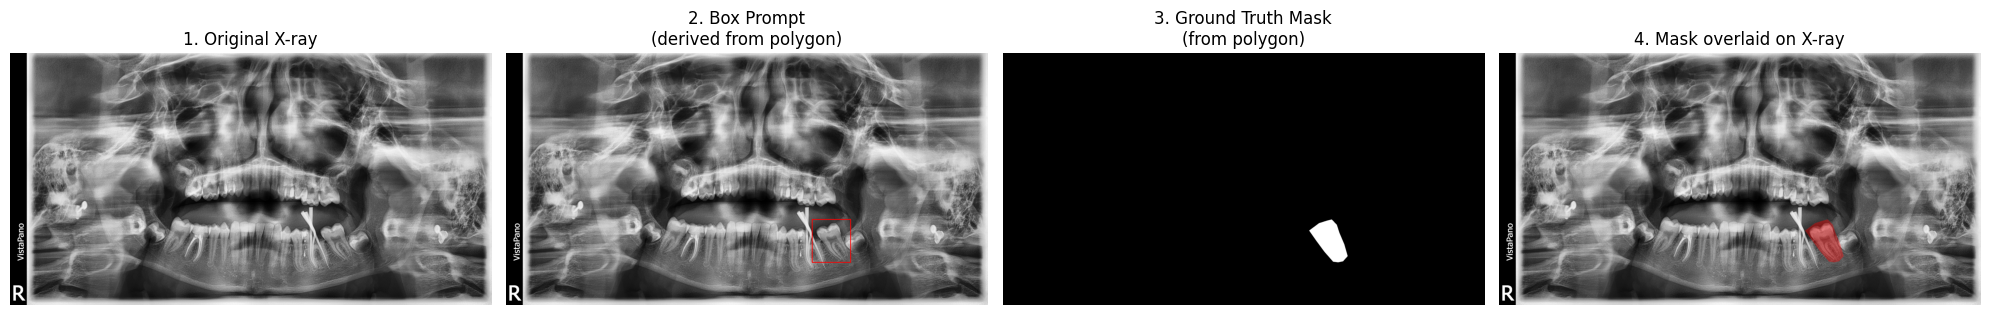

Saved to /content/drive/MyDrive/sam-dental/mask_explainer.png


In [ ]:
# ============================================================
# REGENERATE mask_explainer.png USING A REAL DENTEX SAMPLE
# ============================================================
import json, os
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import cv2

# Rebuild the caries annotations (adjust path if needed)
json_path = "/content/drive/MyDrive/dentex_train/training_data/quadrant-enumeration-disease/train_quadrant_enumeration_disease.json"
image_dir = "/content/drive/MyDrive/dentex_train/training_data/quadrant-enumeration-disease/xrays"

with open(json_path) as f:
    data = json.load(f)

caries_annotations = [ann for ann in data["annotations"] if ann["category_id_3"] == 1]
image_lookup = {img["id"]: img for img in data["images"]}

print(f"Files currently in xrays folder: {len(os.listdir(image_dir))}")

def polygon_to_mask(segmentation, width, height):
    mask = Image.new("L", (width, height), 0)
    for poly in segmentation:
        points = [(poly[i], poly[i+1]) for i in range(0, len(poly), 2)]
        ImageDraw.Draw(mask).polygon(points, outline=1, fill=1)
    return np.array(mask)

# Find the first caries annotation whose image file actually exists
sample_ann = None
image_info = None

for ann in caries_annotations:
    candidate_info = image_lookup[ann["image_id"]]
    candidate_path = os.path.join(image_dir, candidate_info["file_name"])
    if os.path.exists(candidate_path):
        sample_ann = ann
        image_info = candidate_info
        break

if sample_ann is None:
    raise RuntimeError("No valid caries-annotated image found in your local xrays folder.")

image_path = os.path.join(image_dir, image_info["file_name"])
print(f"Using: {image_info['file_name']}")

image = Image.open(image_path).convert("RGB")
image_arr = np.array(image)

mask = polygon_to_mask(sample_ann["segmentation"], image_info["width"], image_info["height"])

# Compute bounding box from the polygon (matches your box-prompt derivation)
box = sample_ann["bbox"]  # [x, y, w, h]
x_min, y_min, w, h = box
x_max, y_max = x_min + w, y_min + h

# Draw box on a copy of the image
img_with_box = image_arr.copy()
cv2.rectangle(img_with_box, (int(x_min), int(y_min)), (int(x_max), int(y_max)), (255, 0, 0), 4)

# Overlay mask on the original image
overlay = image_arr.copy()
overlay[mask > 0] = [255, 0, 0]
blended = cv2.addWeighted(image_arr, 0.6, overlay, 0.4, 0)

# Plot 4 panels
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(image_arr)
axes[0].set_title("1. Original X-ray")
axes[0].axis("off")

axes[1].imshow(img_with_box)
axes[1].set_title("2. Box Prompt\n(derived from polygon)")
axes[1].axis("off")

axes[2].imshow(mask, cmap="gray")
axes[2].set_title("3. Ground Truth Mask\n(from polygon)")
axes[2].axis("off")

axes[3].imshow(blended)
axes[3].set_title("4. Mask overlaid on X-ray")
axes[3].axis("off")

plt.tight_layout()
save_path = "/content/drive/MyDrive/sam-dental/mask_explainer.png"
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved to {save_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
test_pairs: 171 samples
Loading models...


Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

All models loaded.
Running inference on sample 82...
Running inference on sample 38...
Running inference on sample 101...
Running inference on sample 166...


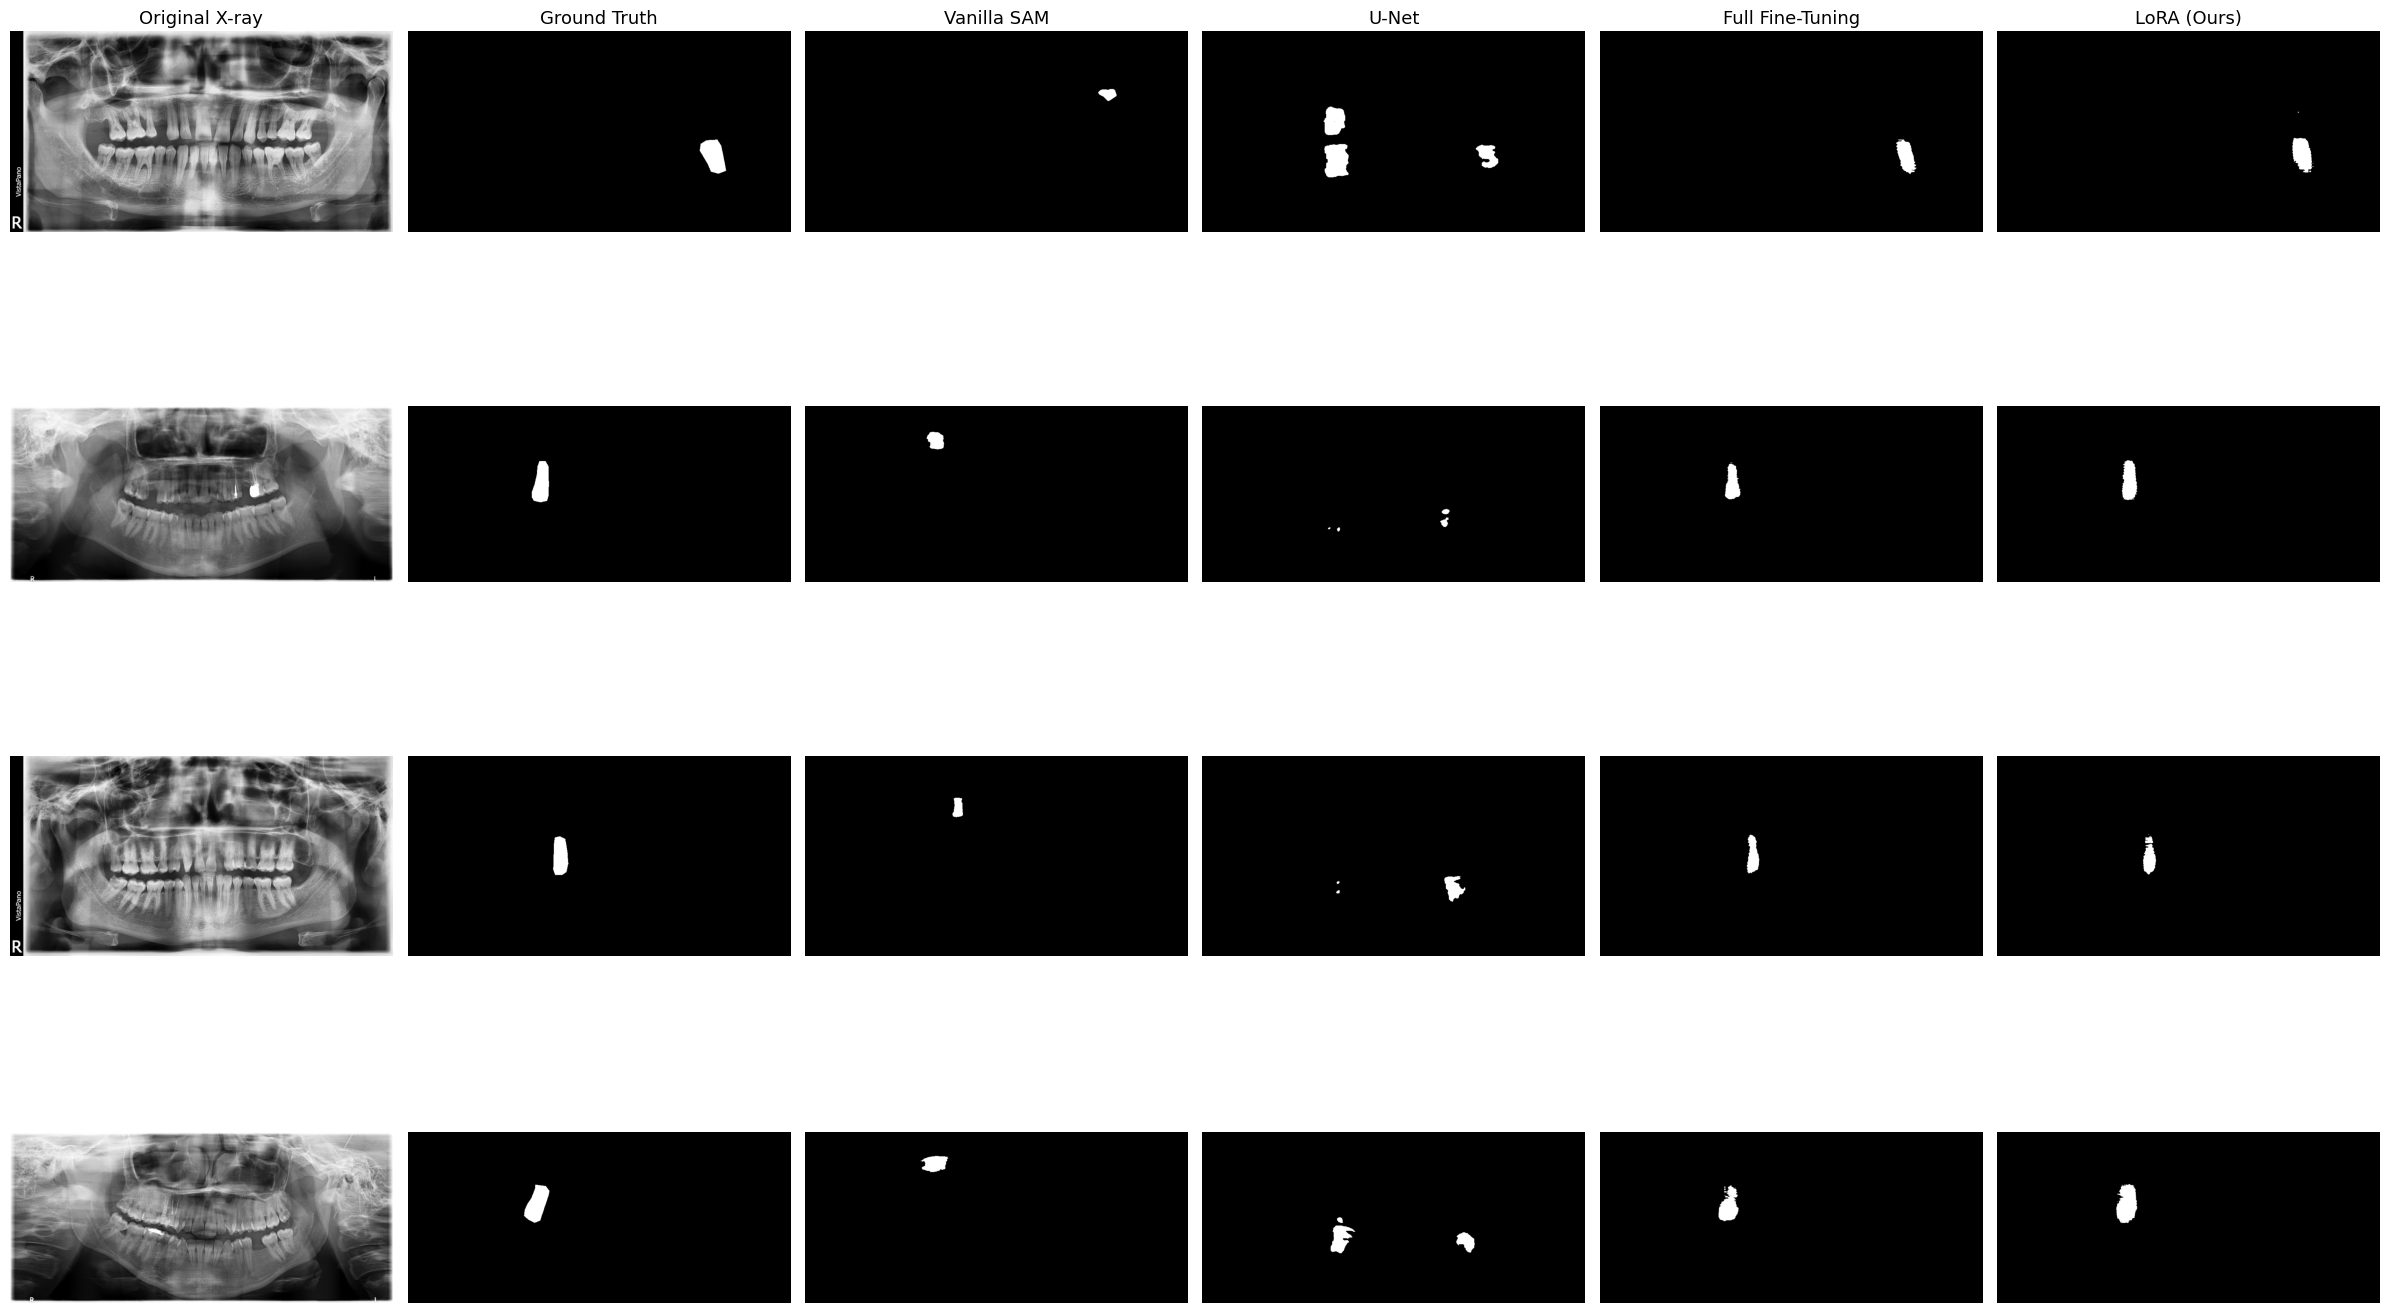

Saved to /content/drive/MyDrive/sam-dental/qualitative_comparison.png


In [ ]:
# ============================================================
# QUALITATIVE COMPARISON CHART
# Runs Vanilla SAM, U-Net, Full Fine-Tuning, and LoRA on the
# same sample test images and plots predictions side by side.
# Run this as one cell in Colab.
# ============================================================

import json, os, random
import numpy as np
from PIL import Image, ImageDraw
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
import torchvision.transforms as T
import matplotlib.pyplot as plt
from transformers import AutoProcessor, AutoModelForMaskGeneration
from peft import PeftModel
from google.colab import drive

drive.mount('/content/drive')
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
MAX_SIZE = 1024

# ============================================================
# REBUILD test_pairs (same seed/logic as the rest of the project)
# ============================================================
json_path = "/content/drive/MyDrive/dentex_train/training_data/quadrant-enumeration-disease/train_quadrant_enumeration_disease.json"
image_dir = "/content/drive/MyDrive/dentex_train/training_data/quadrant-enumeration-disease/xrays"

with open(json_path) as f:
    data = json.load(f)

caries_annotations = [ann for ann in data["annotations"] if ann["category_id_3"] == 1]
image_lookup = {img["id"]: img for img in data["images"]}

dataset_pairs = []
for ann in caries_annotations:
    img_info = image_lookup[ann["image_id"]]
    image_path = os.path.join(image_dir, img_info["file_name"])
    if not os.path.exists(image_path):
        continue
    dataset_pairs.append({
        "image_path": image_path, "segmentation": ann["segmentation"],
        "box": ann["bbox"], "image_id": ann["image_id"],
        "width": img_info["width"], "height": img_info["height"],
    })

unique_images = set(p["image_id"] for p in dataset_pairs)
random.seed(42)
unique_image_ids = list(unique_images)
random.shuffle(unique_image_ids)
selected_ids = unique_image_ids[:100]
test_ids = set(selected_ids[50:100])
test_pairs = [p for p in dataset_pairs if p["image_id"] in test_ids]
print(f"test_pairs: {len(test_pairs)} samples")

# ============================================================
# HELPERS
# ============================================================
def polygon_to_mask(segmentation, width, height):
    mask = Image.new("L", (width, height), 0)
    for poly in segmentation:
        points = [(poly[i], poly[i+1]) for i in range(0, len(poly), 2)]
        ImageDraw.Draw(mask).polygon(points, outline=1, fill=1)
    return np.array(mask)

class CariesDataset(Dataset):
    """For SAM-based models (Vanilla SAM, Full FT, LoRA)."""
    def __init__(self, pairs, processor, train=False):
        self.pairs = pairs
        self.processor = processor
        self.train = train
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, idx):
        item = self.pairs[idx]
        image = Image.open(item["image_path"]).convert("RGB")
        orig_w, orig_h = image.size
        full_mask = polygon_to_mask(item["segmentation"], item["width"], item["height"])
        image.thumbnail((MAX_SIZE, MAX_SIZE), Image.LANCZOS)
        new_w, new_h = image.size
        scale_x, scale_y = new_w / orig_w, new_h / orig_h
        mask_img = Image.fromarray(full_mask).resize((new_w, new_h), Image.NEAREST)
        mask = np.array(mask_img).astype(np.float32)
        box = item["box"]
        scaled_box = [box[0]*scale_x, box[1]*scale_y, box[2]*scale_x, box[3]*scale_y]
        box_xyxy = [scaled_box[0], scaled_box[1], scaled_box[0]+scaled_box[2], scaled_box[1]+scaled_box[3]]
        inputs = self.processor(image, input_boxes=[[box_xyxy]], return_tensors="pt")
        inputs = {k: v.squeeze(0) for k, v in inputs.items()}
        inputs["gt_mask"] = torch.tensor(mask)
        return inputs

def sam_predict(model, processor, item, device):
    ds = CariesDataset([item], processor, train=False)
    batch = ds[0]
    gt_mask = batch.pop("gt_mask").numpy()
    inputs = {k: v.unsqueeze(0).to(device) for k, v in batch.items()}
    with torch.no_grad():
        outputs = model(**inputs)
        pred_mask = outputs.pred_masks[:, :, 0]
        pred_mask = F.interpolate(pred_mask, size=gt_mask.shape[-2:], mode="bilinear", align_corners=False)
        pred_mask = torch.sigmoid(pred_mask).squeeze().cpu().numpy()
    return (pred_mask > 0.5).astype(np.uint8), gt_mask

# ---- U-Net architecture (matches earlier training) ----
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, features=[64, 128, 256, 512]):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(2)
        for f in features:
            self.downs.append(DoubleConv(in_ch, f))
            in_ch = f
        self.bottleneck = DoubleConv(features[-1], features[-1]*2)
        for f in reversed(features):
            self.ups.append(nn.ConvTranspose2d(f*2, f, 2, stride=2))
            self.ups.append(DoubleConv(f*2, f))
        self.final_conv = nn.Conv2d(features[0], out_ch, 1)
    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x)
            skips.append(x)
            x = self.pool(x)
        x = self.bottleneck(x)
        skips = skips[::-1]
        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip = skips[idx // 2]
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:])
            x = torch.cat((skip, x), dim=1)
            x = self.ups[idx+1](x)
        return self.final_conv(x)

UNET_SIZE = 256
unet_transform = T.Compose([
    T.Resize((UNET_SIZE, UNET_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def unet_predict(model, item, device):
    image = Image.open(item["image_path"]).convert("RGB")
    orig_size = image.size  # (w, h)
    image_t = unet_transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = torch.sigmoid(model(image_t)).squeeze().cpu().numpy()
    # Resize prediction back to original image size for fair side-by-side display
    pred_img = Image.fromarray((pred * 255).astype(np.uint8)).resize(orig_size, Image.BILINEAR)
    pred_binary = (np.array(pred_img) > 127).astype(np.uint8)
    return pred_binary

# ============================================================
# LOAD ALL MODELS
# ============================================================
print("Loading models...")
processor = AutoProcessor.from_pretrained("facebook/sam-vit-base")

vanilla_model = AutoModelForMaskGeneration.from_pretrained("facebook/sam-vit-base").to(device)

fullft_base = AutoModelForMaskGeneration.from_pretrained("facebook/sam-vit-base")
fullft_model = AutoModelForMaskGeneration.from_pretrained(
    "/content/drive/MyDrive/sam-dental/fullft_checkpoints_50/epoch_20"
).to(device)

lora_base = AutoModelForMaskGeneration.from_pretrained("facebook/sam-vit-base")
lora_model = PeftModel.from_pretrained(
    lora_base, "/content/drive/MyDrive/sam-dental/checkpoints_50/epoch_20"
).to(device)

unet_model = UNet(in_ch=3, out_ch=1).to(device)
unet_model.load_state_dict(torch.load(
    "/content/drive/MyDrive/sam-dental/unet_checkpoints_50/unet_final.pth",
    map_location=device
))

for m in [vanilla_model, fullft_model, lora_model, unet_model]:
    m.eval()

print("All models loaded.")

# ============================================================
# PICK SAMPLE IMAGES AND RUN ALL MODELS
# ============================================================
NUM_EXAMPLES = 4
random.seed(7)  # different seed than data split, just for picking display examples
sample_indices = random.sample(range(len(test_pairs)), NUM_EXAMPLES)

results = []
for idx in sample_indices:
    item = test_pairs[idx]
    print(f"Running inference on sample {idx}...")

    vanilla_pred, gt_mask = sam_predict(vanilla_model, processor, item, device)
    fullft_pred, _ = sam_predict(fullft_model, processor, item, device)
    lora_pred, _ = sam_predict(lora_model, processor, item, device)
    unet_pred_full = unet_predict(unet_model, item, device)

    # Resize unet prediction to match gt_mask shape (same resolution used by SAM pipeline)
    unet_pred = np.array(Image.fromarray(unet_pred_full * 255).resize(
        (gt_mask.shape[1], gt_mask.shape[0]), Image.NEAREST)) > 127

    image = Image.open(item["image_path"]).convert("RGB")
    image.thumbnail((MAX_SIZE, MAX_SIZE), Image.LANCZOS)
    image_arr = np.array(image)

    results.append({
        "image": image_arr,
        "gt": gt_mask,
        "vanilla": vanilla_pred,
        "unet": unet_pred,
        "fullft": fullft_pred,
        "lora": lora_pred,
    })

# ============================================================
# PLOT GRID
# ============================================================
col_titles = ["Original X-ray", "Ground Truth", "Vanilla SAM", "U-Net", "Full Fine-Tuning", "LoRA (Ours)"]
fig, axes = plt.subplots(NUM_EXAMPLES, 6, figsize=(24, 4 * NUM_EXAMPLES))

for i, r in enumerate(results):
    panels = [r["image"], r["gt"], r["vanilla"], r["unet"], r["fullft"], r["lora"]]
    for j, panel in enumerate(panels):
        if j == 0:
            axes[i, j].imshow(panel)
        else:
            axes[i, j].imshow(panel, cmap="gray")
        if i == 0:
            axes[i, j].set_title(col_titles[j], fontsize=13)
        axes[i, j].axis("off")

plt.tight_layout()
save_path = "/content/drive/MyDrive/sam-dental/qualitative_comparison.png"
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved to {save_path}")

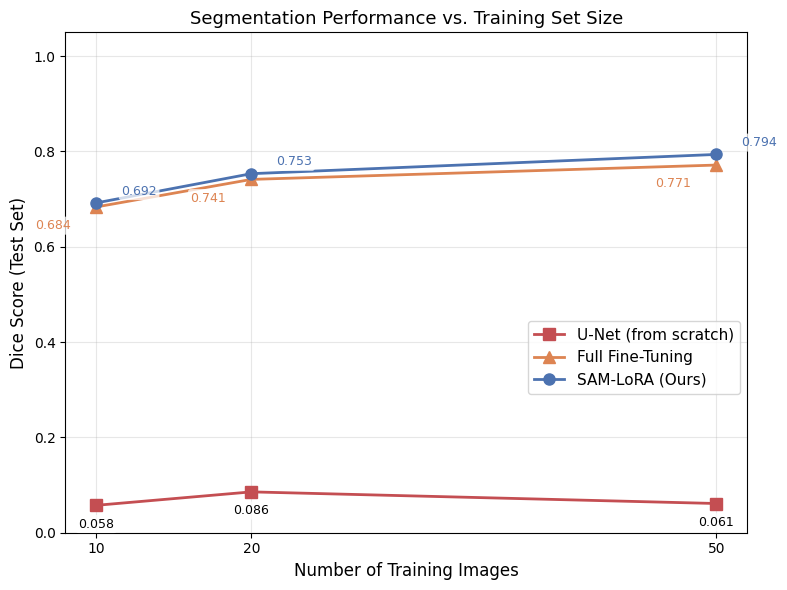

Saved to /content/drive/MyDrive/sam-dental/main_results_lineplot.png


In [ ]:
import matplotlib.pyplot as plt

training_sizes = [10, 20, 50]

unet_dice = [0.0575, 0.0857, 0.0613]
fullft_dice = [0.6836, 0.7414, 0.7715]
lora_dice = [0.6921, 0.7534, 0.7938]

plt.figure(figsize=(8, 6))

plt.plot(training_sizes, unet_dice, marker='s', linewidth=2, markersize=8, label='U-Net (from scratch)', color='#C44E52')
plt.plot(training_sizes, fullft_dice, marker='^', linewidth=2, markersize=8, label='Full Fine-Tuning', color='#DD8452')
plt.plot(training_sizes, lora_dice, marker='o', linewidth=2, markersize=8, label='SAM-LoRA (Ours)', color='#4C72B0')

plt.xlabel('Number of Training Images', fontsize=12)
plt.ylabel('Dice Score (Test Set)', fontsize=12)
plt.title('Segmentation Performance vs. Training Set Size', fontsize=13)
plt.xticks(training_sizes, ['10', '20', '50'])
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)

bbox_style = dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.75)

for x, y in zip(training_sizes, unet_dice):
    plt.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(0, -16),
                 ha='center', fontsize=9, bbox=bbox_style)

for x, y in zip(training_sizes, lora_dice):
    plt.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(18, 6),
                 ha='left', fontsize=9, color='#4C72B0', bbox=bbox_style)

for x, y in zip(training_sizes, fullft_dice):
    plt.annotate(f'{y:.3f}', (x, y), textcoords="offset points", xytext=(-18, -16),
                 ha='right', fontsize=9, color='#DD8452', bbox=bbox_style)

# Legend moved to middle-right, an empty area of the chart (between 0.2-0.45 on y-axis)
plt.legend(fontsize=11, loc='center right', bbox_to_anchor=(1.0, 0.35))

plt.tight_layout()
save_path = "/content/drive/MyDrive/sam-dental/main_results_lineplot.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved to {save_path}")

Correct pixels: 7,994,440
Incorrect pixels: 23,480


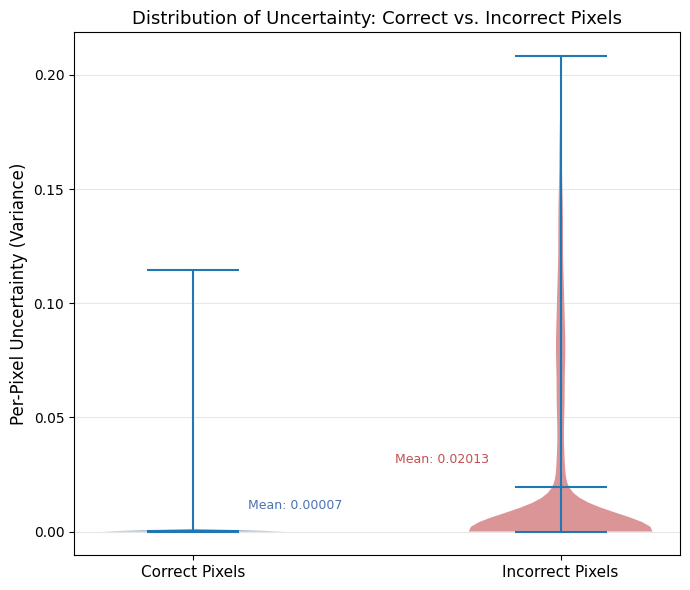

Saved to /content/drive/MyDrive/sam-dental/uncertainty_distribution_violin.png


In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

with open("/content/drive/MyDrive/sam-dental/mc_dropout_results_small.pkl", "rb") as f:
    all_results = pickle.load(f)

correct_uncertainties = []
incorrect_uncertainties = []

for r in all_results:
    gt = (r["gt_mask"] > 0.5).astype(np.uint8)
    pred_binary = (r["mean_pred"] > 0.5).astype(np.uint8)
    uncertainty = r["uncertainty"]

    error_map = (pred_binary != gt)

    correct_uncertainties.append(uncertainty[~error_map].flatten())
    incorrect_uncertainties.append(uncertainty[error_map].flatten())

correct_all = np.concatenate(correct_uncertainties)
incorrect_all = np.concatenate(incorrect_uncertainties)

print(f"Correct pixels: {len(correct_all):,}")
print(f"Incorrect pixels: {len(incorrect_all):,}")

# Subsample correct pixels for readability (there are usually FAR more correct
# than incorrect pixels, since most of the image is background)
np.random.seed(42)
max_points = 5000
if len(correct_all) > max_points:
    correct_sample = np.random.choice(correct_all, max_points, replace=False)
else:
    correct_sample = correct_all

if len(incorrect_all) > max_points:
    incorrect_sample = np.random.choice(incorrect_all, max_points, replace=False)
else:
    incorrect_sample = incorrect_all

# ============================================================
# VIOLIN PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(7, 6))

data = [correct_sample, incorrect_sample]
parts = ax.violinplot(data, showmeans=True, showmedians=False)

colors = ['#4C72B0', '#C44E52']
for pc, color in zip(parts['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.6)

ax.set_xticks([1, 2])
ax.set_xticklabels(['Correct Pixels', 'Incorrect Pixels'], fontsize=11)
ax.set_ylabel('Per-Pixel Uncertainty (Variance)', fontsize=12)
ax.set_title('Distribution of Uncertainty: Correct vs. Incorrect Pixels', fontsize=13)
ax.grid(True, alpha=0.3, axis='y')

# Annotate means
ax.annotate(f'Mean: {correct_all.mean():.5f}', xy=(1, correct_all.mean()),
            xytext=(1.15, correct_all.mean() + 0.01), fontsize=9, color='#4C72B0')
ax.annotate(f'Mean: {incorrect_all.mean():.5f}', xy=(2, incorrect_all.mean()),
            xytext=(1.55, incorrect_all.mean() + 0.01), fontsize=9, color='#C44E52')

plt.tight_layout()
save_path = "/content/drive/MyDrive/sam-dental/uncertainty_distribution_violin.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved to {save_path}")

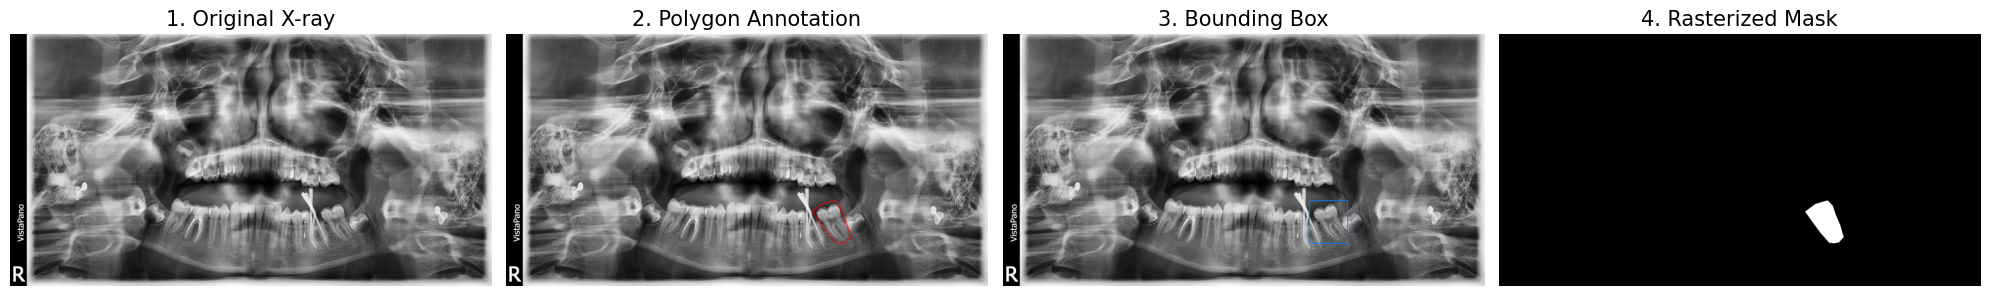

Saved to /content/drive/MyDrive/sam-dental/data_prep_pipeline.png


In [ ]:
import json, os
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import cv2

json_path = "/content/drive/MyDrive/dentex_train/training_data/quadrant-enumeration-disease/train_quadrant_enumeration_disease.json"
image_dir = "/content/drive/MyDrive/dentex_train/training_data/quadrant-enumeration-disease/xrays"

with open(json_path) as f:
    data = json.load(f)

caries_annotations = [ann for ann in data["annotations"] if ann["category_id_3"] == 1]
image_lookup = {img["id"]: img for img in data["images"]}

def polygon_to_mask(segmentation, width, height):
    mask = Image.new("L", (width, height), 0)
    for poly in segmentation:
        points = [(poly[i], poly[i+1]) for i in range(0, len(poly), 2)]
        ImageDraw.Draw(mask).polygon(points, outline=1, fill=1)
    return np.array(mask)

# Find first valid sample
sample_ann = None
image_info = None
for ann in caries_annotations:
    candidate_info = image_lookup[ann["image_id"]]
    candidate_path = os.path.join(image_dir, candidate_info["file_name"])
    if os.path.exists(candidate_path):
        sample_ann = ann
        image_info = candidate_info
        break

image_path = os.path.join(image_dir, image_info["file_name"])
image = Image.open(image_path).convert("RGB")
image_arr = np.array(image)

mask = polygon_to_mask(sample_ann["segmentation"], image_info["width"], image_info["height"])

box = sample_ann["bbox"]
x_min, y_min, w, h = box
x_max, y_max = x_min + w, y_min + h

# Panel 1: Original
panel1 = image_arr.copy()

# Panel 2: Polygon outline drawn on the image
panel2 = image_arr.copy()
for poly in sample_ann["segmentation"]:
    points = np.array([(poly[i], poly[i+1]) for i in range(0, len(poly), 2)], dtype=np.int32)
    cv2.polylines(panel2, [points], isClosed=True, color=(255, 0, 0), thickness=3)

# Panel 3: Bounding box drawn on the image
panel3 = image_arr.copy()
cv2.rectangle(panel3, (int(x_min), int(y_min)), (int(x_max), int(y_max)), (0, 128, 255), 4)

# Panel 4: Rasterized binary mask
panel4 = mask * 255

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
titles = ["1. Original X-ray", "2. Polygon Annotation", "3. Bounding Box", "4. Rasterized Mask"]
panels = [panel1, panel2, panel3, panel4]

for ax, title, panel in zip(axes, titles, panels):
    if panel.ndim == 2:
        ax.imshow(panel, cmap="gray")
    else:
        ax.imshow(panel)
    ax.set_title(title, fontsize=15)
    ax.axis("off")

plt.tight_layout()
save_path = "/content/drive/MyDrive/sam-dental/data_prep_pipeline.png"
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved to {save_path}")

Correct pixels:   7,994,440
Incorrect pixels: 23,480
Mean uncertainty (correct):   0.00007
Mean uncertainty (incorrect): 0.02013
Ratio (incorrect / correct):  288.2x
Fraction of exactly-zero variance (correct):   68.141%
Fraction of exactly-zero variance (incorrect): 6.316%


/tmp/ipykernel_4402/1695283703.py:88: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'$10^{{{int(t)}}}$' for t in yticks])


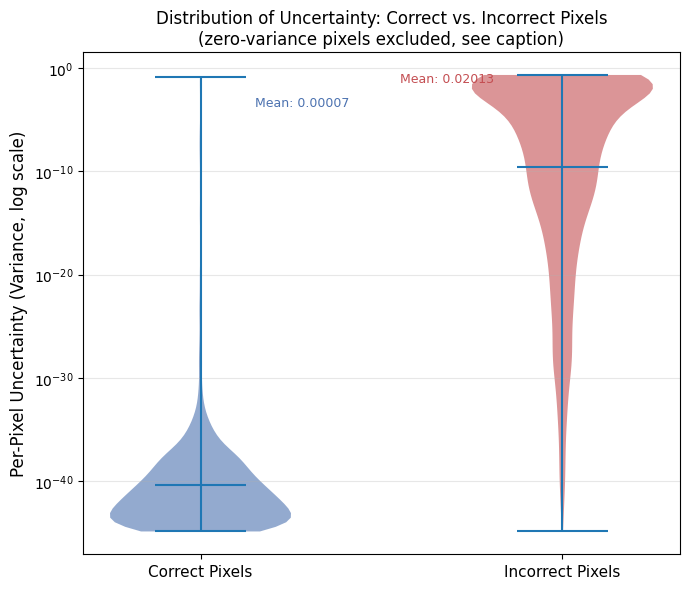

Saved to /content/drive/MyDrive/sam-dental/uncertainty_distribution_violin_logscale.png


In [2]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

# ============================================================
# LOAD RESULTS
# ============================================================
with open("/content/drive/MyDrive/sam-dental/mc_dropout_results_small.pkl", "rb") as f:
    all_results = pickle.load(f)

correct_uncertainties = []
incorrect_uncertainties = []

for r in all_results:
    gt = (r["gt_mask"] > 0.5).astype(np.uint8)
    pred_binary = (r["mean_pred"] > 0.5).astype(np.uint8)
    uncertainty = r["uncertainty"]

    error_map = (pred_binary != gt)

    correct_uncertainties.append(uncertainty[~error_map].flatten())
    incorrect_uncertainties.append(uncertainty[error_map].flatten())

correct_all = np.concatenate(correct_uncertainties)
incorrect_all = np.concatenate(incorrect_uncertainties)

print(f"Correct pixels:   {len(correct_all):,}")
print(f"Incorrect pixels: {len(incorrect_all):,}")
print(f"Mean uncertainty (correct):   {correct_all.mean():.5f}")
print(f"Mean uncertainty (incorrect): {incorrect_all.mean():.5f}")
print(f"Ratio (incorrect / correct):  {incorrect_all.mean() / correct_all.mean():.1f}x")

# ============================================================
# IMPORTANT: many "correct" pixels have exactly zero variance
# (the model was certain, and correct). Zero can't be log-transformed,
# so we report what fraction that is, then drop exact zeros before
# taking the log — rather than flooring them to a fake epsilon that
# shows up as a false cluster in the plot.
# ============================================================
frac_zero_correct = np.mean(correct_all == 0)
frac_zero_incorrect = np.mean(incorrect_all == 0)
print(f"Fraction of exactly-zero variance (correct):   {frac_zero_correct:.3%}")
print(f"Fraction of exactly-zero variance (incorrect): {frac_zero_incorrect:.3%}")

correct_nonzero = correct_all[correct_all > 0]
incorrect_nonzero = incorrect_all[incorrect_all > 0]

# Subsample for readability
np.random.seed(42)
max_points = 5000

correct_sample = (
    np.random.choice(correct_nonzero, max_points, replace=False)
    if len(correct_nonzero) > max_points else correct_nonzero
)
incorrect_sample = (
    np.random.choice(incorrect_nonzero, max_points, replace=False)
    if len(incorrect_nonzero) > max_points else incorrect_nonzero
)

# Log-transform BEFORE plotting, so the KDE itself is computed in log-space
correct_log = np.log10(correct_sample)
incorrect_log = np.log10(incorrect_sample)

# ============================================================
# VIOLIN PLOT, KDE COMPUTED IN LOG-SPACE
# ============================================================
fig, ax = plt.subplots(figsize=(7, 6))

data = [correct_log, incorrect_log]
parts = ax.violinplot(data, showmeans=True, showmedians=False)

colors = ['#4C72B0', '#C44E52']
for pc, color in zip(parts['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.6)

ax.set_xticks([1, 2])
ax.set_xticklabels(['Correct Pixels', 'Incorrect Pixels'], fontsize=11)
ax.set_ylabel('Per-Pixel Uncertainty (Variance, log scale)', fontsize=12)
ax.set_title('Distribution of Uncertainty: Correct vs. Incorrect Pixels\n(zero-variance pixels excluded, see caption)', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

# Relabel the y-axis from log10 values back to readable original units
yticks = ax.get_yticks()
ax.set_yticklabels([f'$10^{{{int(t)}}}$' for t in yticks])

# Annotate true means (computed on ALL pixels including zeros, so this
# matches your reported 0.00007 / 0.02013 figures) at their log10 position
mean_correct_log = np.log10(max(correct_all.mean(), 1e-10))
mean_incorrect_log = np.log10(incorrect_all.mean())

ax.annotate(
    f'Mean: {correct_all.mean():.5f}',
    xy=(1, mean_correct_log),
    xytext=(1.15, mean_correct_log + 0.5),
    fontsize=9, color='#4C72B0'
)
ax.annotate(
    f'Mean: {incorrect_all.mean():.5f}',
    xy=(2, mean_incorrect_log),
    xytext=(1.55, mean_incorrect_log + 0.3),
    fontsize=9, color='#C44E52'
)

plt.tight_layout()

save_dir = "/content/drive/MyDrive/sam-dental"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "uncertainty_distribution_violin_logscale.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved to {save_path}")